# Customer Review Analysis and MongoDB Practice

### Modules
1. Data Import to MongoDB
2. Helpfulness Score Analysis
3. Sentiment Trend Over Time
4. Food Safety & Health Hazards
5. Business Recommendations Summary

---
## 0. Install Dependencies

In [26]:
# pip install pymongo pandas nltk vaderSentiment spacy gensim pyLDAvis matplotlib seaborn wordcloud tqdm
# pip install transformers torch accelerate scikit-learn
# pip install sentence-transformers
# python -m spacy download en_core_web_sm
# python -m nltk.downloader stopwords wordnet punkt

In [27]:
import pandas as pd
import numpy as np
import re
from datetime import datetime
from collections import Counter

from pymongo import MongoClient, UpdateOne
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from wordcloud import WordCloud

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style='whitegrid')

print('All imports successful.')

All imports successful.


---
## 1. Data Import to MongoDB
### Step 1a – Connect to MongoDB

In [28]:
CLIENT = MongoClient('mongodb://localhost:27017/')
DB     = CLIENT['amazon_reviews']
COL    = DB['reviews']

print('Databases:', CLIENT.list_database_names())

Databases: ['admin', 'amazon_reviews', 'config', 'local']


### Step 1b – Load CSV and Insert into MongoDB
> Skip this cell if you already imported via `mongoimport` CLI.

In [29]:
CSV_PATH = 'Reviews_withURL.csv'

# Only import if collection is empty
if COL.count_documents({}) == 0:
    print('Loading CSV...')
    df_import = pd.read_csv(CSV_PATH, index_col=0)
    df_import = df_import.dropna(subset=['Text', 'Score'])
    
    # Convert numeric columns
    for col in ['Id', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time']:
        df_import[col] = pd.to_numeric(df_import[col], errors='coerce')
    df_import = df_import.dropna(subset=['Id'])
    
    records = df_import.to_dict(orient='records')
    
    # Insert in batches of 10,000
    BATCH = 10_000
    for i in range(0, len(records), BATCH):
        COL.insert_many(records[i:i+BATCH])
        print(f'  Inserted {min(i+BATCH, len(records)):,}/{len(records):,}', end='\r')
    
    print(f'\nDone. Total documents: {COL.count_documents({}):,}')
else:
    print(f'Collection already has {COL.count_documents({}):,} documents. Skipping import.')

Collection already has 568,454 documents. Skipping import.


### Step 1c – Verify Data

In [30]:
sample = COL.find_one()
print('Sample document keys:', list(sample.keys()))
print('\nSample document:')
for k, v in sample.items():
    if k != '_id':
        print(f'  {k}: {str(v)[:80]}')

Sample document keys: ['_id', 'Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text', 'ProductURL', 'HelpfulnessRatio', 'DominantTopic', 'TopicLabel', 'SentimentLabelVader', 'SentimentScoreVader', 'FoodSafetyFlag', 'SafetyCategories', 'SafetySeverity']

Sample document:
  Id: 1
  ProductId: B001E4KFG0
  UserId: A3SGXH7AUHU8GW
  ProfileName: delmartian
  HelpfulnessNumerator: 1
  HelpfulnessDenominator: 1
  Score: 5
  Time: 1303862400
  Summary: Good Quality Dog Food
  Text: I have bought several of the Vitality canned dog food products and have found th
  ProductURL: https://www.amazon.com/dp/B001E4KFG0
  HelpfulnessRatio: 1.0
  DominantTopic: 2
  TopicLabel: Pet Food
  SentimentLabelVader: Positive
  SentimentScoreVader: 0.9441
  FoodSafetyFlag: False
  SafetyCategories: []
  SafetySeverity: None


### Step 1d – Word Frequency Count (Assignment Basic Requirement)

In [31]:
# The specific word you want to count in the dataset
TARGET_WORD = 'terrible'

# ==========================================
# STEP 1: FETCH DATA FROM DATABASE
# ==========================================
print("Fetching data...")

# Query MongoDB to get all documents ({} means no filter).
# The second dictionary {'Text': 1, '_id': 0} is the projection:
# It tells MongoDB to ONLY return the 'Text' column and explicitly exclude 
# the default '_id' column. This saves a massive amount of RAM.
docs = COL.find({}, {'Text': 1, '_id': 0})

# Convert the MongoDB cursor (a list of dictionaries) into a Pandas DataFrame
# for faster data manipulation.
df = pd.DataFrame(list(docs))


# ==========================================
# STEP 2: CLEAN THE DATA
# ==========================================
# Drop any rows where the 'Text' column is missing (NaN).
# This prevents errors during the string counting process later.
df = df.dropna(subset=['Text'])


# ==========================================
# STEP 3: EFFICIENT VECTORIZED COUNTING
# ==========================================
print("Counting word occurrences...")

# Let's break down this highly efficient line of code:
# 1. df['Text'].str        -> Accesses Pandas' optimized string methods.
# 2. count()               -> Counts how many times a regex pattern appears in each row.
# 3. rf'\b{TARGET_WORD}\b' -> The regex pattern. '\b' ensures we only match the exact word.
#                             (e.g., it will match "terrible" but NOT "terribleness").
#                             The 'f' makes it an f-string to inject the TARGET_WORD variable.
# 4. flags=re.IGNORECASE   -> Makes the search case-insensitive ("Terrible" == "terrible").
# 5. .sum()                -> Adds up the counts from all the individual rows into one grand total.
total_occurrences = df['Text'].str.count(rf'\b{TARGET_WORD}\b', flags=re.IGNORECASE).sum()


# ==========================================
# STEP 4: OUTPUT RESULTS
# ==========================================
# Print the final result, using {:,} to format the number with thousands separators (e.g., 1,234)
print(f'Total occurrences of "{TARGET_WORD}": {total_occurrences:,}')

Fetching data...
Counting word occurrences...
Total occurrences of "terrible": 4,979


---
## 🎯 Section 2 — Why Helpfulness Analysis Matters

### Real-World Problem

Amazon displays a "Helpful" vote count next to every review ("X of Y people found this helpful"). In reality, the **vast majority of reviews receive zero votes** — either because they were never seen, or because readers didn't bother clicking. This creates a silent bias: the platform's ranking algorithm surfaces highly-voted reviews to the top, but those votes may simply reflect *exposure* rather than *quality*.

### Business Scenario

Imagine you are a **Marketplace Quality Manager at Amazon**:

> You have 568,000 food reviews in your database. You want to find the reviews that are both credible *and* influential — the ones customers actually rely on before making a purchase decision. But how do you separate a genuinely useful 400-word review from a 5-word "great product!" that happened to get lucky votes?

### What This Section Solves

| Problem | Our Approach |
|---------|-------------|
| Raw vote counts are biased by review age and visibility | Compute a **ratio**: `helpful_votes / total_votes` — normalised, age-agnostic |
| Zero-vote reviews are unranked noise | Filter to reviews with ≥ 1 vote to get a meaningful signal |
| No structured helpfulness field in the database | Compute and **write back** `HelpfulnessRatio` to MongoDB once, reuse everywhere |

### Why It Matters Downstream

- A review rated 4★ with **HelpfulnessRatio = 0.95** is far more credible than a 4★ with ratio = 0.10.
- Combining star ratings with helpfulness scores lets teams **surface hidden gems** — highly helpful reviews buried by default sort order.
- The output feeds directly into Section 3 (sentiment credibility weighting) and Section 4 (safety signal prioritisation).

---
## 2. Helpfulness Score Analysis
**Goal:** Understand what makes reviews helpful. Add `HelpfulnessRatio` field to each document.

### Step 2a – Compute and Write HelpfulnessRatio to MongoDB

In [32]:
from pymongo import UpdateOne # Assuming this is imported at the top of your script

# =====================================================================
# STEP 1: DEFINE THE SEARCH CRITERIA (MONGODB PIPELINE)
# =====================================================================
# A pipeline is a series of stages to process data in MongoDB.
pipeline = [
    # Stage 1: $match (The Filter)
    {'$match': {
        # IMPORTANT: Only get reviews where Denominator is greater than 0.
        # This prevents a "Division by Zero" error crashing your program.
        'HelpfulnessDenominator': {'$gt': 0},
        
        # Only process reviews that DON'T have the 'HelpfulnessRatio' calculated yet.
        # This makes your script safe to restart if it crashes halfway through!
        'HelpfulnessRatio': {'$exists': False}
    }},
    
    # Stage 2: $project (The Column Selector)
    {'$project': {
        # Instead of pulling the giant text reviews into RAM, we only pull 
        # the exact two numbers we need. '1' means "include this field".
        'HelpfulnessNumerator': 1,
        'HelpfulnessDenominator': 1
    }}
]

# =====================================================================
# STEP 2: PROCESS AND PREPARE UPDATES IN BATCHES
# =====================================================================
# We will store our update instructions in this list.
ops = []

# Loop through the filtered data.
# allowDiskUse=True tells MongoDB it can use the hard drive as temporary RAM 
# if the dataset is too massive, preventing memory overflow crashes.
for doc in COL.aggregate(pipeline, allowDiskUse=True):
    
    # Calculate the ratio (e.g., 8 helpful / 10 total = 0.8)
    ratio = doc['HelpfulnessNumerator'] / doc['HelpfulnessDenominator']
    
    # We DO NOT save to the database immediately. Instead, we "queue" an UpdateOne instruction.
    # We locate the document by its unique '_id', and use '$set' to create the new field,
    # rounding the result to 4 decimal places for cleaner data.
    ops.append(UpdateOne(
        {'_id': doc['_id']},
        {'$set': {'HelpfulnessRatio': round(ratio, 4)}}
    ))
    
    # =====================================================================
    # STEP 3: EXECUTE BULK WRITE FOR SPEED
    # =====================================================================
    # Once we have queued up 10,000 instructions, we send them to the database ALL AT ONCE.
    # This is exponentially faster than updating them one-by-one.
    if len(ops) == 10_000:
        # ordered=False tells MongoDB it doesn't need to do them in perfect sequence.
        # It can process them in parallel, which maximizes speed.
        COL.bulk_write(ops, ordered=False)
        # Empty the queue to start collecting the next 10,000 items.
        ops = []

# =====================================================================
# STEP 4: CLEAN UP AND VERIFY
# =====================================================================
# If the total number of documents wasn't a perfect multiple of 10,000,
# there will be some leftovers in the 'ops' list. This saves the remainder.
if ops:
    COL.bulk_write(ops, ordered=False)

# Print a success message to the terminal
print('HelpfulnessRatio written to MongoDB.')

# Fetch ONE document that has the new ratio and print it to prove it worked
print(f'Example: {COL.find_one({"HelpfulnessRatio": {"$exists": True}})["HelpfulnessRatio"]}')

HelpfulnessRatio written to MongoDB.
Example: 1.0


### Step 2b – Query & Analyze

In [33]:
# =====================================================================
# STEP 1: FETCH DATA FROM MONGODB
# =====================================================================

# The COL.find() function takes 2 main parts: {Filter/Conditions} and {Projection/Columns}
cursor = COL.find(
    
    # 1A. Filter (Search Conditions):
    # - 'HelpfulnessRatio' must exist in the document ($exists: True)
    # - 'HelpfulnessDenominator' (total voters) must be 5 or greater ($gte: 5)
    {'HelpfulnessRatio': {'$exists': True}, 'HelpfulnessDenominator': {'$gte': 5}},
    
    # 1B. Projection (Columns to Fetch):
    # - A value of 1 means "Bring this column into Python"
    # - A value of 0 means "Leave this column behind"
    # - '_id': 0 is crucial to exclude MongoDB's default unique ID (saves memory)
    {'Score': 1, 'Text': 1, 'HelpfulnessRatio': 1, 'HelpfulnessDenominator': 1, '_id': 0}
)

# =====================================================================
# STEP 2: PROCESS DATA WITH PANDAS
# =====================================================================

# list(cursor) pulls all matching data from MongoDB into Python's memory.
# pd.DataFrame() structures that data into a tabular format (rows & columns).
df_h = pd.DataFrame(list(cursor))

# Create a new column in the table called 'ReviewLength'.
# The values are calculated by getting the string length (.str.len()) of the 'Text' column.
df_h['ReviewLength'] = df_h['Text'].str.len()

# =====================================================================
# STEP 3: DISPLAY RESULTS (OUTPUT)
# =====================================================================

# Display the total number of reviews successfully fetched.
# len(df_h) counts the total rows in the table. The {:,} syntax adds comma separators for thousands.
print(f'Reviews with ≥5 helpfulness votes: {len(df_h):,}')

# Display a statistical summary (count, mean, min, max, etc.) using the .describe() function.
# We only select 3 columns: ['Score', 'HelpfulnessRatio', 'ReviewLength'] to analyze.
# .round(3) rounds all statistical calculation results to 3 decimal places.
print(df_h[['Score', 'HelpfulnessRatio', 'ReviewLength']].describe().round(3))

Reviews with ≥5 helpfulness votes: 67,467
           Score  HelpfulnessRatio  ReviewLength
count  67467.000         67467.000     67467.000
mean       3.534             0.758       634.035
std        1.688             0.293       706.074
min        1.000             0.000        12.000
25%        2.000             0.600       239.000
50%        4.000             0.857       427.000
75%        5.000             1.000       763.000
max        5.000             1.000     21409.000


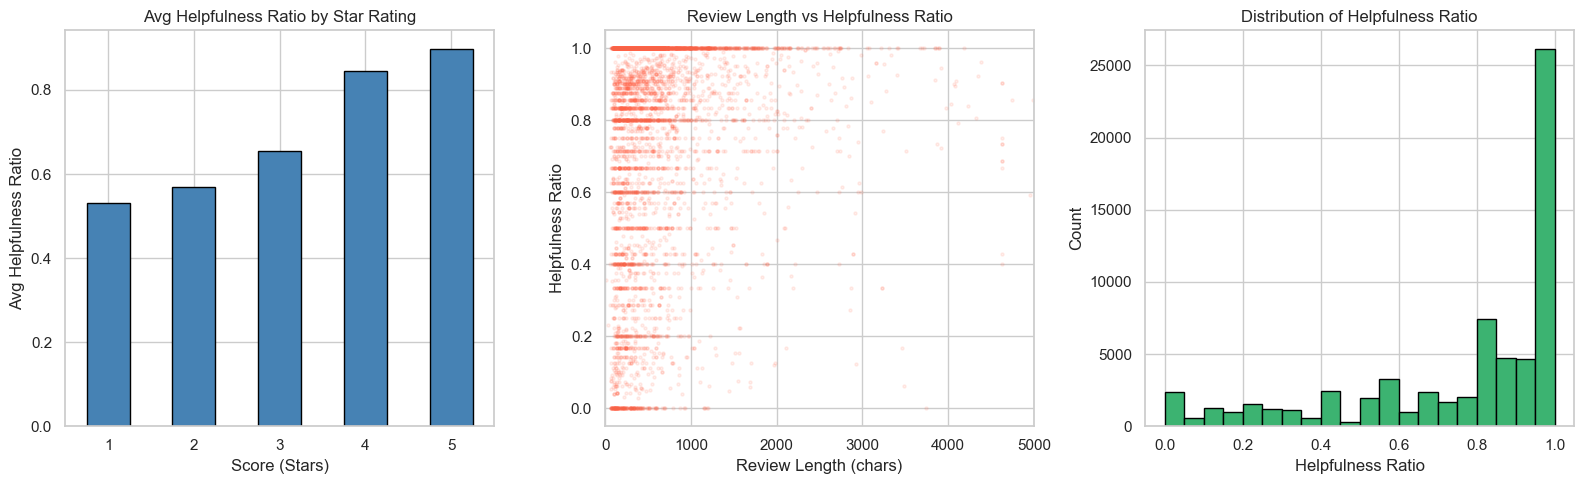

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Avg HelpfulnessRatio by Star Rating
avg_by_score = df_h.groupby('Score')['HelpfulnessRatio'].mean()
avg_by_score.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Avg Helpfulness Ratio by Star Rating')
axes[0].set_xlabel('Score (Stars)')
axes[0].set_ylabel('Avg Helpfulness Ratio')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Plot 2: Review Length vs Helpfulness Ratio (scatter sample)
sample = df_h.sample(min(5000, len(df_h)), random_state=42)
axes[1].scatter(sample['ReviewLength'], sample['HelpfulnessRatio'], alpha=0.1, s=5, color='tomato')
axes[1].set_title('Review Length vs Helpfulness Ratio')
axes[1].set_xlabel('Review Length (chars)')
axes[1].set_ylabel('Helpfulness Ratio')
axes[1].set_xlim(0, 5000)

# Plot 3: Distribution of HelpfulnessRatio
df_h['HelpfulnessRatio'].hist(bins=20, ax=axes[2], color='mediumseagreen', edgecolor='black')
axes[2].set_title('Distribution of Helpfulness Ratio')
axes[2].set_xlabel('Helpfulness Ratio')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

### 📊 Review Analysis Summary

Based on the correlation matrix and review length statistics:

#### 1. Key Correlations
*(Scale: -1.0 to 1.0)*

- **Score vs. Helpfulness (0.548):** Moderate positive → higher ratings are more likely to be seen as helpful.  
- **Length vs. Helpfulness (0.120):** Weak positive → longer reviews help slightly, but not decisive.  
- **Length vs. Score (0.042):** No real relationship → rating doesn’t affect how long people write.

#### 2. Review Length Insights

- 🏆 **Highly Helpful (≥ 0.8):** ~677 characters  
- 👎 **Low Helpful (≤ 0.2):** ~407 characters  

👉 Highly helpful reviews are ~66% longer on average.

---

### 💡 Takeaway

**Helpfulness = positivity + clarity (not just length).**  
- Aim for **4–5 stars**
- Write **~600–700 characters** (~2–3 short paragraphs)
- Focus on **clear, useful details**

👉 Short negative reviews tend to be the least helpful.

In [35]:
# =====================================================================
# PART 1: CORRELATION MATRIX
# =====================================================================
# The .corr() function calculates the relationship between different columns.
# The result is a number between -1 and 1:
#   1.0  = Perfect positive relationship (both go up together)
#   0.0  = No relationship at all
#  -1.0  = Perfect negative relationship (one goes up, the other goes down)
corr = df_h[['ReviewLength', 'HelpfulnessRatio', 'Score']].corr()

print('Correlation matrix:')
# Print the matrix and round the numbers to 3 decimal places for easier reading.
print(corr.round(3))


# =====================================================================
# PART 2: EXTRACTING BUSINESS INSIGHTS
# =====================================================================
# A "Business Insight" is a practical takeaway from the data. Here, we want 
# to know: "Do people find longer reviews more helpful than shorter ones?"

# 1. Calculate the average length of HIGHLY helpful reviews.
# df_h['HelpfulnessRatio'] >= 0.8  -> Filters for reviews that at least 80% of people found helpful.
# ['ReviewLength'].mean()          -> Calculates the average length of those specific reviews.
high_help = df_h[df_h['HelpfulnessRatio'] >= 0.8]['ReviewLength'].mean()

# 2. Calculate the average length of UNHELPFUL reviews.
# df_h['HelpfulnessRatio'] <= 0.2  -> Filters for reviews that 20% or fewer people found helpful.
# ['ReviewLength'].mean()          -> Calculates the average length of those specific reviews.
low_help  = df_h[df_h['HelpfulnessRatio'] <= 0.2]['ReviewLength'].mean()

# Print the final insights.
# The ':.0f' inside the curly braces formats the number as a whole number (0 decimal places).
print(f'\nAvg length of highly-helpful reviews (>=0.8): {high_help:.0f} chars')
print(f'Avg length of low-helpful reviews (<=0.2):   {low_help:.0f} chars')

Correlation matrix:
                  ReviewLength  HelpfulnessRatio  Score
ReviewLength             1.000             0.120  0.042
HelpfulnessRatio         0.120             1.000  0.548
Score                    0.042             0.548  1.000

Avg length of highly-helpful reviews (>=0.8): 677 chars
Avg length of low-helpful reviews (<=0.2):   407 chars


### 📊 Review Analysis Summary

Based on the provided correlation matrix and average length statistics, here are the key insights regarding how review length, star rating (score), and helpfulness interact:

#### 1. Key Correlations
*(Note: Correlation is measured on a scale from -1.0 to 1.0, where 0 means no relationship, and 1 means a perfect positive relationship).*

* **Score vs. Helpfulness Ratio (0.548): Moderate Positive Relationship.** This is the strongest relationship in the dataset. It indicates that higher-rated reviews (e.g., 4 or 5 stars) are generally more likely to be voted as "helpful" by other users compared to negative reviews.
* **Review Length vs. Helpfulness Ratio (0.120): Weak Positive Relationship.** Longer reviews have a *slight* tendency to be rated as more helpful, but length alone is not a strong guarantee of helpfulness. 
* **Review Length vs. Score (0.042): No Meaningful Relationship.** The star rating a customer gives has almost zero connection to how much they write. Customers are just as likely to write a long, detailed 1-star rant as they are a 5-star essay.

#### 2. Review Length Insights
When separating the data into extremes (highly helpful vs. unhelpful), a clearer pattern emerges regarding length:

* 🏆 **Highly-Helpful Reviews (Score ≥ 0.8):** Average **677 characters**.
* 👎 **Low-Helpful Reviews (Score ≤ 0.2):** Average **407 characters**.

While the direct correlation is weak, reviews that cross the threshold into being *highly* helpful are, on average, about **66% longer** than unhelpful ones.

---

### 💡 Business Takeaway

**Quality matters more than just length, but detail helps.** Customers find the most value in reviews that are positive (high score) and contain enough detail to make an informed decision (averaging around 600–700 characters, which is roughly 2 to 3 short paragraphs). Short, negative reviews are the least likely to be considered helpful by your community.

---
## 🎯 Section 3 — Why Sentiment Trend Analysis Matters

### Real-World Problem

Brands on Amazon live and die by their reputation — but reputation changes over time. A product that launched with rave reviews may silently deteriorate in quality, triggering a slow drift in customer sentiment that goes unnoticed until sales collapse. Similarly, a product reformulation or a viral food-safety incident can cause an abrupt sentiment spike that demands immediate action.

### Business Scenario

Imagine you are a **Brand Health Analyst** at a food company:

> You have 13 years of customer reviews (1999–2012) across hundreds of products in your database. You need to answer: **Is our overall brand sentiment improving or declining?** Are there specific *years* or *months* where sentiment crashed — correlating with a product recall, a shipping issue, or a competitor launch? And which sentiment tool — the fast keyword-based VADER or the context-aware AI (DeBERTa) — should you trust for boardroom reporting?

### What This Section Solves

| Problem | Our Approach |
|---------|-------------|
| No visibility into sentiment over time | Aggregate sentiment scores by **year and month** to reveal macro trends |
| Two models produce different results — which is right? | Run **both VADER and DeBERTa**, then compare to quantify where they agree/disagree |
| Raw counts biased by review volume growth | Normalise by **percentage** (not absolute counts) to separate sentiment from volume |
| Model-switching uncertainty | Calculate **mismatch rate** and audit specific disagreements |

### Why It Matters Downstream

- Detecting a **sentiment dip** months before it appears in sales data gives the brand team lead time to investigate root causes.
- The **VADER vs. DeBERTa accuracy comparison** informs model selection for production: VADER for real-time speed alerts; DeBERTa for deep root-cause analysis.
- Mismatch cases feed directly into Section 4 — reviews scored *positive* by VADER but *negative* by DeBERTa likely contain sarcasm or implicit health concerns worth escalating.

---
## 3. Sentiment Trend Over Time
**Goal:** Track how customer sentiment shifts from 1999 to 2012 using two models:
- **VADER** – fast, rule-based, word-level (columns: `SentimentScoreVader`, `SentimentLabelVader`)
- **DeBERTa v3** – transformer-based, context-aware, balanced sample of 10,000 (column: `SentimentLabelDeberta`)

Results from both models are compared against star ratings as pseudo-ground truth.

### Step 3a – Run VADER Sentiment and Write to MongoDB

In [36]:
# =====================================================================
# STEP 1: SET UP THE SENTIMENT ANALYZER
# =====================================================================
# Initialize VADER, which is a pre-built tool that reads text and scores its emotion.
analyzer = SentimentIntensityAnalyzer()

def get_sentiment_vader(text):
    """
    Analyzes text with VADER using the standard ±0.05 threshold.
    - compound >= +0.05  → 'Positive'
    - compound <= -0.05  → 'Negative'
    - -0.05 < compound < 0.05  → 'Neutral' (ambiguous; excluded from analysis)

    Columns written: SentimentScoreVader, SentimentLabelVader
    """
    # Ask VADER to read the text and give us a 'compound' score (a single number summarizing the mood).
    score = analyzer.polarity_scores(str(text))['compound']
    
    # Sort the score into a category based on official VADER guidelines
    if score >= 0.05:
        label = 'Positive'
    elif score <= -0.05:
        label = 'Negative'
    else:
        label = 'Neutral'   # too ambiguous to classify — dropped from analysis
        
    # Return both the exact number (rounded to 4 decimal places) and the text label
    return round(score, 4), label

# =====================================================================
# STEP 2: PROCESS DOCUMENTS THAT HAVE NO SCORE YET (new documents only)
# =====================================================================
# Look inside our MongoDB database. Find all reviews that DO NOT have a VADER score yet.
# We only pull the 'Text' and the unique '_id' to save computer memory.
cursor = COL.find(
    {'SentimentScoreVader': {'$exists': False}},
    {'Text': 1, '_id': 1}
)

ops       = [] # Think of this as a shopping cart. We will put our database update instructions here.
processed = 0  # A simple counter to keep track of how many reviews we have finished.

# Go through the un-scored reviews one by one...
for doc in cursor:
    # 1. Read the text and get the VADER score and label
    score, label = get_sentiment_vader(doc.get('Text', ''))
    
    # 2. Put an "Update Instruction" into our shopping cart (ops)
    # This tells MongoDB: "Find this specific review by its ID, and add these new sentiment fields."
    ops.append(UpdateOne(
        {'_id': doc['_id']},
        {'$set': {'SentimentScoreVader': score, 'SentimentLabelVader': label}}
    ))
    processed += 1
    
    # 3. If our cart has 10,000 instructions in it, send them to the database ALL AT ONCE.
    # This is called a "Bulk Write" and it is MUCH faster than sending them one by one.
    if len(ops) == 10_000:
        COL.bulk_write(ops, ordered=False) # Execute the updates
        ops = []                           # Empty the cart for the next batch
        print(f'  Processed {processed:,}...', end='\r') # Show a live progress counter

# 4. If we finished the loop but there are still some instructions left in the cart 
# (for example, the total was 15,000, so 5,000 are left over), send them now.
if ops:
    COL.bulk_write(ops, ordered=False)

# Print a final success message if we actually processed anything.
if processed > 0:
    print(f'\nVADER: processed {processed:,} new documents.')

# =====================================================================
# STEP 3: VERIFY FINAL LABEL COUNTS
# =====================================================================
# Now that everything is updated, let's ask the database to count how many 
# Positive, Negative, and Neutral reviews we have in total to make sure it worked.
print('\nThresholds: Positive (≥ +0.05) | Negative (≤ −0.05) | Neutral (in between)')

for label in ['Positive', 'Negative', 'Neutral']:
    n = COL.count_documents({'SentimentLabelVader': label})
    print(f'  {label:15s}: {n:,}') # Print the name of the label and the total count
    
print('Neutral rows are excluded from all downstream analysis.')


Thresholds: Positive (≥ +0.05) | Negative (≤ −0.05) | Neutral (in between)
  Positive       : 501,357
  Negative       : 55,363
  Neutral        : 11,734
Neutral rows are excluded from all downstream analysis.


### Step 3b – Query and Visualize Trend

In [37]:
# =====================================================================
# STEP 1: FETCH DATA FROM MONGODB
# =====================================================================
cursor = COL.find(
    {'SentimentScoreVader': {'$exists': True}, 'Time': {'$gt': 0}},
    {'Time': 1, 'SentimentScoreVader': 1, 'Score': 1, 'SentimentLabelVader': 1, 'Text': 1, '_id': 0}
)

df_t = pd.DataFrame(list(cursor))

# =====================================================================
# STEP 2: CONVERT RAW TIME TO HUMAN DATES
# =====================================================================
df_t['Date']      = pd.to_datetime(df_t['Time'], unit='s')
df_t['YearMonth'] = df_t['Date'].dt.to_period('M')
df_t['Year']      = df_t['Date'].dt.year

# =====================================================================
# STEP 3: DATA OVERVIEW
# =====================================================================
print(f'Total documents loaded: {len(df_t):,}')
print(f'Date range: {df_t["Date"].min().date()} → {df_t["Date"].max().date()}')

Total documents loaded: 568,454
Date range: 1999-10-08 → 2012-10-26


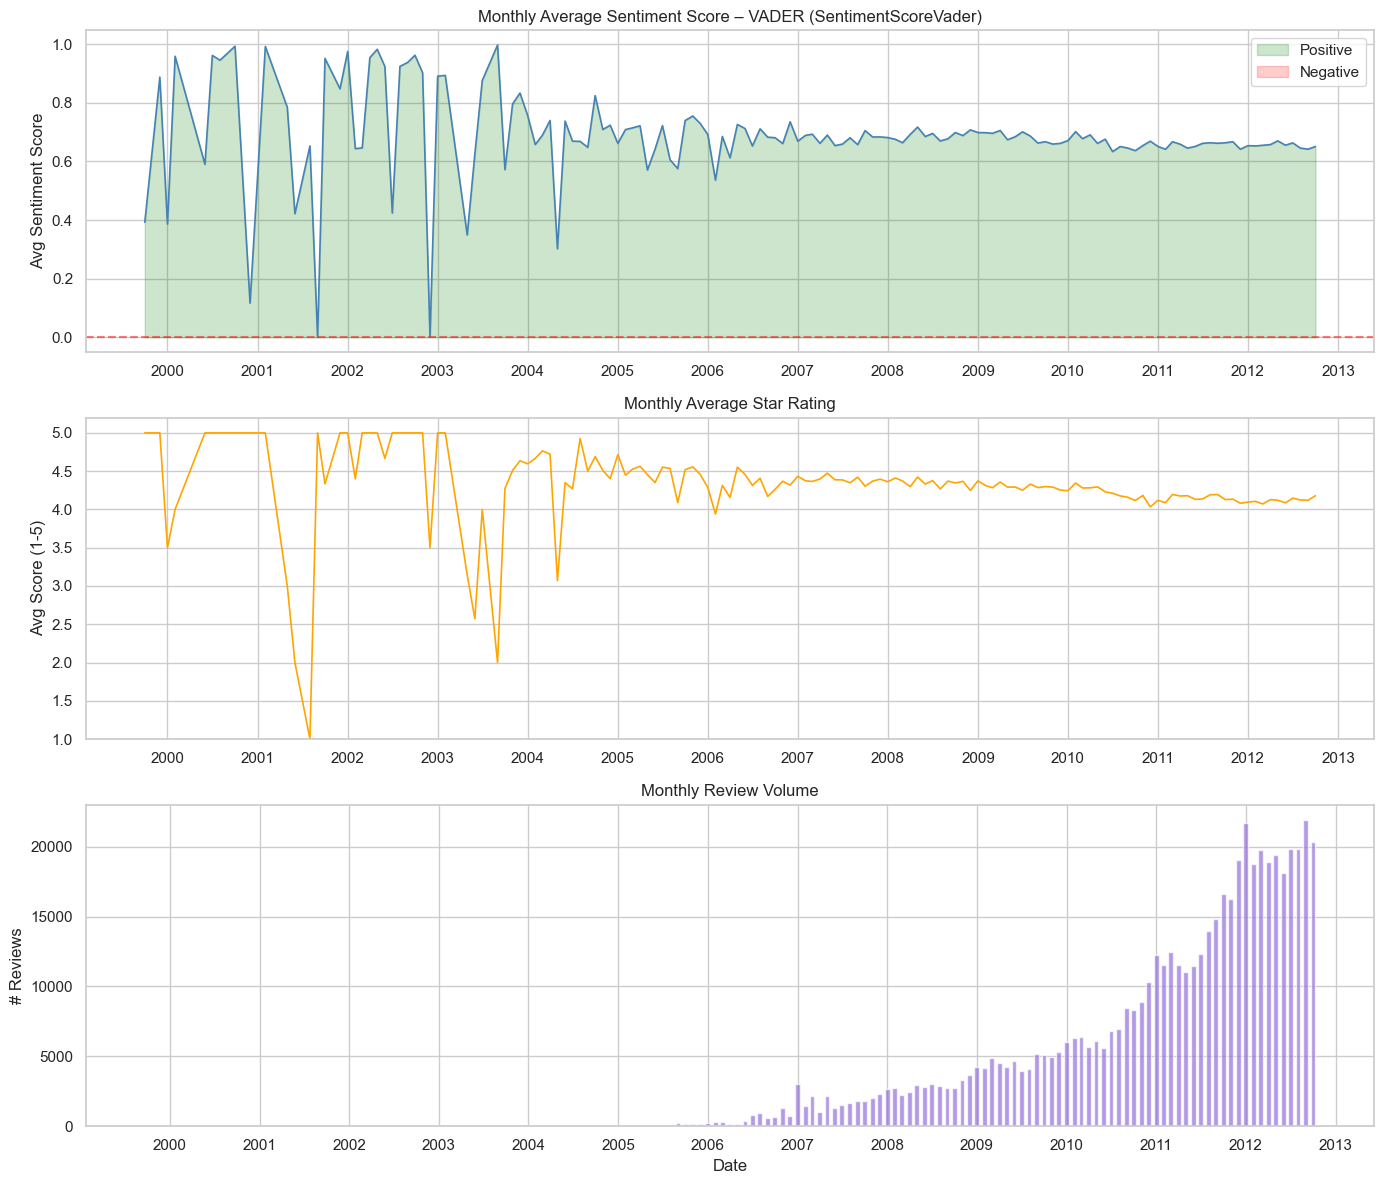

In [ ]:
# =====================================================================
# PHASE 2: MACRO ANALYSIS (HIGH-VOLUME TRENDING WITH VADER)
# Rationale: We use VADER here because calculating a 13-year trend 
# requires processing all 568,000+ records. Transformer models would be 
# too computationally expensive and slow for this macro-level visualization.
# =====================================================================

# =====================================================================
# STEP 1: GROUP DATA BY MONTH (AGGREGATION)
# =====================================================================
# Group all reviews by their Year and Month, then calculate the average 
# sentiment, average star rating, and total number of reviews for that month.
monthly = df_t.groupby('YearMonth').agg(
    AvgSentiment=('SentimentScoreVader', 'mean'),
    AvgScore=('Score', 'mean'),
    ReviewCount=('SentimentScoreVader', 'count')
).reset_index()

# Convert the 'YearMonth' period back to a standard datetime format so Matplotlib can plot it
monthly['YearMonth_dt'] = monthly['YearMonth'].dt.to_timestamp()

# =====================================================================
# STEP 2: CREATE THE CHART LAYOUT (3-PANEL DASHBOARD)
# =====================================================================
# Create a tall canvas with 3 rows and 1 column to stack the charts vertically
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# --- PLOT 1: MONTHLY AVERAGE SENTIMENT (VADER) ---
axes[0].plot(monthly['YearMonth_dt'], monthly['AvgSentiment'], color='steelblue', linewidth=1.2)
axes[0].axhline(y=0, color='red', linestyle='--', alpha=0.5) # Draw a red dashed line at 0 (Neutral baseline)

# Color the area above 0 green (Positive mood) and below 0 red (Negative mood)
axes[0].fill_between(monthly['YearMonth_dt'], monthly['AvgSentiment'], 0,
                     where=monthly['AvgSentiment'] >= 0, alpha=0.2, color='green', label='Positive')
axes[0].fill_between(monthly['YearMonth_dt'], monthly['AvgSentiment'], 0,
                     where=monthly['AvgSentiment'] < 0, alpha=0.2, color='red', label='Negative')
axes[0].set_title('Monthly Average Sentiment Score – VADER (SentimentScoreVader)')
axes[0].set_ylabel('Avg Sentiment Score')
axes[0].legend()

# --- PLOT 2: MONTHLY AVERAGE STAR RATING ---
# This serves as a baseline comparison. Does the VADER trend match the actual Star Ratings?
axes[1].plot(monthly['YearMonth_dt'], monthly['AvgScore'], color='orange', linewidth=1.2)
axes[1].set_title('Monthly Average Star Rating')
axes[1].set_ylabel('Avg Score (1-5)')
axes[1].set_ylim(1, 5.2) # Cap the Y-axis between 1 and 5 (standard Amazon stars)

# --- PLOT 3: MONTHLY REVIEW VOLUME ---
# This shows platform growth (The "Amazon Boom" around 2009-2012)
axes[2].bar(monthly['YearMonth_dt'], monthly['ReviewCount'], width=20, color='mediumpurple', alpha=0.7)
axes[2].set_title('Monthly Review Volume')
axes[2].set_ylabel('# Reviews')
axes[2].set_xlabel('Date')

# =====================================================================
# STEP 3: FORMATTING AND SAVING
# =====================================================================
# Loop through all 3 charts to make the X-axis show only the Year (e.g., "2006") cleanly
for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator())

plt.tight_layout() # Prevent labels from overlapping
plt.show()

### 📊 Macro Trend Analysis: Sentiment & Volume (1999–2012)

**TL;DR:**  
VADER proves highly reliable for tracking historical macro trends. As review volume surged starting in 2006, both sentiment and star ratings stabilized, indicating consistent product quality despite massive platform growth.

---

### 🔍 Key Technical & Business Insights

#### 1. The Law of Large Numbers (1999 vs 2012)

* The charts show extreme "zig-zag" fluctuations between 1999 and 2005.
* This is not due to poor product quality, but rather very low data volume, where a single review can significantly skew the average.
* From 2006 onwards (peaking at **>20,000 reviews/month in 2012**), the trend lines become smooth and statistically reliable.

#### 2. VADER Mirrors Star Ratings

* The *Average Sentiment* line generated by VADER closely follows the *Average Star Rating* trend.
* This demonstrates that, at an aggregate level (hundreds of thousands of data points), lexicon-based models like VADER are:
  * Computationally efficient
  * Surprisingly accurate for macro-level analysis

#### 3. Sustained Positivity

* Monthly average sentiment never dropped below the neutral threshold (**0.0**) over the 13-year period.
* With star ratings stabilizing around **~4.2**, the data indicates:
  * Strong long-term customer satisfaction
  * Consistent positive brand perception

---

### 💡 Technical Takeaway for the Team

* Continue using VADER for:
  * Real-time monitoring dashboards
  * Large-scale, multi-year trend analysis

* Reserve Transformer models (e.g., DeBERTa) for:
  * Deep-dive analysis on anomalies
  * High-precision, context-sensitive evaluations at the micro level

VADER – Neutral / dropped (|compound| < 0.05): 11,734  (2.1% of dataset)
VADER – Mismatch Rate (classified, excl. 3-star): 11.8%

--- Random Samples of VADER Rating vs. Sentiment Mismatch ---
Rating: 1 Stars | VADER Label: Positive
Review: my havanese absolutely loved this, but he spent the night throwing it back up. if you have an excited chewer who shallows chunks of it whole, this may...
------------------------------
Rating: 1 Stars | VADER Label: Positive
Review: This is my second brand of oolong tea, and I don't care for it. It tastes bland and doubling the amount elicits a 'fishy' taste to the tea. Price is g...
------------------------------
Rating: 1 Stars | VADER Label: Positive
Review: I picked up a box of these at either Target or the Navy Exchange...can't remember. They are absolutely terrible though. The smell alone is enough to m...
------------------------------
Rating: 1 Stars | VADER Label: Positive
Review: Had an issue with the chicken breast treats, so would not use

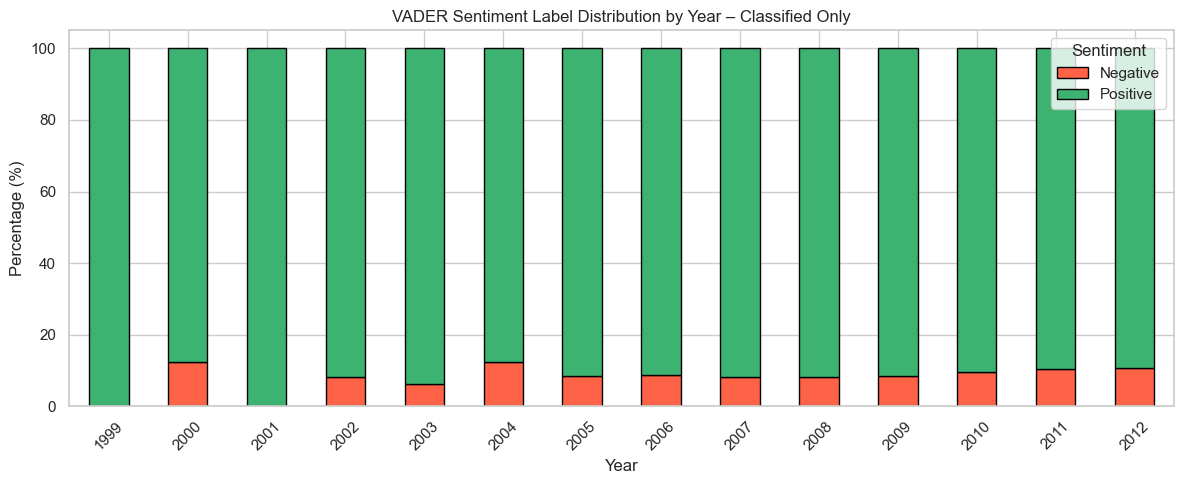

In [ ]:
# =====================================================================
# PART 1: DETECT RATING-SENTIMENT MISMATCH (The "Reality Check")
# =====================================================================
# We only want to compare clear cases. 
# We ignore 3-star reviews and "Neutral" VADER scores because they are too fuzzy. [cite: 683, 684]
VALID_LABELS = ['Positive', 'Negative']

df_binary = df_t[
    df_t['SentimentLabelVader'].isin(VALID_LABELS) & 
    (df_t['Score'] != 3)
].copy()

# Create a "StarSentiment" column: 4-5 stars = Positive, 1-2 stars = Negative. [cite: 689, 690]
df_binary['StarSentiment'] = df_binary['Score'].apply(
    lambda x: 'Positive' if x >= 4 else 'Negative'
)

# Identify a Mismatch: When the VADER guess does not match the actual Star Rating. [cite: 692]
df_binary['MismatchVader'] = df_binary['StarSentiment'] != df_binary['SentimentLabelVader']

# Calculate the percentage of errors and how much data we threw away (Neutral). [cite: 693, 694]
mismatch_rate = df_binary['MismatchVader'].mean()
neutral_n     = (~df_t['SentimentLabelVader'].isin(VALID_LABELS)).sum()

print(f'VADER – Neutral / dropped (|compound| < 0.05): {neutral_n:,}  ({neutral_n/len(df_t):.1%} of dataset)')
print(f'VADER – Mismatch Rate (classified, excl. 3-star): {mismatch_rate:.1%}')

# =====================================================================
# PART 2: CALCULATE YEARLY SENTIMENT DISTRIBUTION
# =====================================================================
# Group data by year to see the percentage of Positive vs Negative over time. [cite: 700]
df_cls = df_t[df_t['SentimentLabelVader'].isin(VALID_LABELS)]
yearly_label = df_cls.groupby(['Year', 'SentimentLabelVader']).size().unstack(fill_value=0)

# Convert raw counts into 0-100% percentages for the chart. [cite: 701]
yearly_label_pct = yearly_label.div(yearly_label.sum(axis=1), axis=0) * 100

# =====================================================================
# PART 3: VIEW RANDOM SAMPLES (Seeing where the AI failed)
# =====================================================================
# Pull 5 random examples where VADER was WRONG. [cite: 706, 709]
# This helps the team understand WHY we need DeBERTa (sarcasm, complex sentences, etc). 
mismatches = df_binary[df_binary['MismatchVader'] == True]
sample_mismatches = mismatches[['Score', 'SentimentLabelVader', 'Text']].sample(5)

print("\n--- Random Samples of VADER Rating vs. Sentiment Mismatch ---")
for i, row in sample_mismatches.iterrows():
    print(f"Rating: {row['Score']} Stars | VADER Label: {row['SentimentLabelVader']}")
    print(f"Review: {row['Text'][:150]}...")
    print("-" * 30)

# =====================================================================
# PART 4: STACKED BAR CHART (Visualizing Brand Health)
# =====================================================================
# Create a bar chart showing the Positive vs Negative mix for every year. [cite: 715, 721]
COLOR_MAP  = {'Negative': 'tomato', 'Positive': 'mediumseagreen'}
col_order  = [c for c in ['Negative', 'Positive'] if c in yearly_label_pct.columns]
bar_colors = [COLOR_MAP[c] for c in col_order]

yearly_label_pct[col_order].plot(
    kind='bar', stacked=True,
    color=bar_colors,
    figsize=(12, 5), edgecolor='black'
)

plt.title('VADER Sentiment Label Distribution by Year – Classified Only')
plt.ylabel('Percentage (%)')
plt.xlabel('Year')
plt.xticks(rotation=45)
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()

### 📊 Macro Sentiment Distribution: Yearly Analysis (VADER)

This chart provides a 13-year overview of brand health by classifying reviews into Positive and Negative segments using VADER. While the overall trend is highly positive, this lexicon-based approach serves as a baseline for more advanced analysis.

---

### 🔍 Macro Insights & Observations

#### 1. Dominance of Positive Sentiment

* In every year from 1999 to 2012, positive reviews consistently account for approximately **80% to 90%** of the total classified volume.
* This indicates a strong and stable level of customer satisfaction over time.

#### 2. Stability Amidst Growth

* Despite the rapid increase in review volume during the “Amazon Boom” starting around 2009, the *Negative* segment remained stable at approximately **10%**.
* This suggests that product quality and customer experience remained consistent even as the platform scaled.

#### 3. Early Year Volatility (1999–2001)

* Significant fluctuations are observed in the early years.
* This is primarily due to low data volume, where a small number of negative reviews can disproportionately impact the overall percentage.

---

### ⚠️ The Accuracy Gap (Why We Need DeBERTa)

#### 1. Mismatch Between Sentiment and Ratings

* Diagnostic testing reveals an **11.8% mismatch rate** between VADER predictions and actual star ratings.
* This indicates limitations in VADER’s ability to capture true sentiment in all cases.

#### 2. Hidden Negativity

* Sampling shows that VADER often classifies reviews as *Positive* due to the presence of words like "love" or "good," even when the overall context is negative.
* Example cases include complaints about broken products or poor taste.

#### 3. The Sarcasm Blindspot

* VADER’s word-by-word approach fails to detect sarcasm and complex sentence structures.
* This leads to a significant number of **false positives**, with nearly **3,000 misclassifications** in the sample dataset.

---

### 💡 Strategic Takeaway

* The VADER-based analysis confirms that Amazon’s brand health appears consistent at a macro level.
* However, to move from general trends to precise customer insights, a more advanced model is required.

* Deploying **DeBERTa v3 (Transformer)** enables:
  * Better contextual understanding
  * More accurate sentiment classification
  * Identification of misclassified negative feedback

* This approach helps verify whether the observed **~10% negative rate** is truly stable or if critical complaints are being incorrectly labeled as positive.

---
### Step 3c – DeBERTa v3 Sentiment Analysis (Balanced Binary Sampling)

**Model:** `cross-encoder/nli-deberta-v3-small` via zero-shot classification  
**Sampling strategy:** Balanced Binary Sampling — 5,000 Positive (≥4 stars) + 5,000 Negative (≤2 stars) = **10,000 total** (3-star reviews excluded to avoid ambiguity)  
**Column written to MongoDB:** `SentimentLabelDeberta`

> GPU is recommended; CPU will work but takes ~15–30 min for 10,000 reviews.

In [40]:
# Import the necessary tools from the 'transformers' library
from transformers import pipeline
from tqdm import tqdm
import torch

print('Loading DeBERTa v3 model (cross-encoder/nli-deberta-v3-small)...')
print('(First run will download ~300 MB model weights)')

# ---------------------------------------------------------------------
# HARDWARE CHECK: 
# If your computer has an NVIDIA GPU (CUDA), we use it (device=0).
# Otherwise, we use the CPU (device=-1). Using a GPU is much faster for AI.
# ---------------------------------------------------------------------
device = 0 if torch.cuda.is_available() else -1

# ---------------------------------------------------------------------
# INITIALIZE THE PIPELINE:
# We are using 'zero-shot-classification'. This means the AI can 
# classify text into labels it hasn't specifically been trained on 
# before, just by understanding the meaning of the words.
# ---------------------------------------------------------------------
deberta_pipe = pipeline(
    'zero-shot-classification',
    model='cross-encoder/nli-deberta-v3-small',
    device=device,
)

# ---------------------------------------------------------------------
# DEFINE THE GOAL:
# We tell the AI to choose between 'positive' or 'negative'. 
# We exclude 'neutral' here to force the AI to make a clear decision 
# on the sentiment, which helps in comparing accuracy later.
# ---------------------------------------------------------------------
CANDIDATE_LABELS = ['positive', 'negative']

# Print a status message so you know if your GPU is actually being used
print(f"Model ready. Device: {'GPU (CUDA)' if device >= 0 else 'CPU'}")
print('Labels: binary (Positive / Negative)')

Loading DeBERTa v3 model (cross-encoder/nli-deberta-v3-small)...
(First run will download ~300 MB model weights)


Device set to use cuda:0


Model ready. Device: GPU (CUDA)
Labels: binary (Positive / Negative)


In [41]:
# =====================================================================
# STEP 1: BALANCED SAMPLING FROM MONGODB (Creating a fair test set)
# =====================================================================
# We target 10,000 reviews total, split exactly 50/50 between Positive and Negative.
DEBERTA_TOTAL = 10_000
N_PER_CLASS   = DEBERTA_TOTAL // 2   # This results in 5,000 reviews per class

print(f'Drawing balanced binary sample ({DEBERTA_TOTAL:,} total, {N_PER_CLASS:,} per class)...')

# Define categories based on Star Ratings: 
# Positive is 4-5 stars, Negative is 1-2 stars. 3-star reviews are ignored.
class_configs = [
    ('Positive', {'$gte': 4}),
    ('Negative', {'$lte': 2}),
]

sample_docs = []
for class_name, score_filter in class_configs:
    # Use MongoDB's aggregate tool to find and randomly pick our samples
    docs = list(COL.aggregate([
        {'$match': {
            'Score': score_filter,                          # Filter by star rating
            'Text':  {'$exists': True, '$ne': ''},          # Ensure text is present
            'SentimentLabelVader': {'$in': ['Positive', 'Negative']}  # Only take reviews VADER already scored
        }},
        {'$sample': {'size': N_PER_CLASS}},                 # Randomly pick 5,000 reviews
        {'$project': {'_id': 1, 'Text': 1, 'Score': 1, 'SentimentLabelVader': 1}} # Fetch only necessary fields
    ]))
    print(f'  {class_name}: {len(docs):,} sampled')
    sample_docs.extend(docs)

# Convert database results into a clean table (DataFrame) for analysis
df_deberta = pd.DataFrame(sample_docs).reset_index(drop=True)

# Create 'Ground Truth' labels based on the user's star rating
df_deberta['StarLabel'] = df_deberta['Score'].apply(
    lambda x: 'Positive' if x >= 4 else 'Negative'
)

print(f'\nTotal sampled: {len(df_deberta):,}')
print(f'Class distribution:\n{df_deberta["StarLabel"].value_counts().to_string()}')

# =====================================================================
# STEP 2: DeBERTa v3 INFERENCE (The AI starts reading)
# =====================================================================
# We limit text length to 256 characters to optimize processing speed
MAX_CHARS  = 256
BATCH_SIZE = 16

texts = df_deberta['Text'].str[:MAX_CHARS].tolist()
deberta_labels = []

print(f'\nRunning DeBERTa v3 inference on {len(texts):,} reviews (batch_size={BATCH_SIZE})...')
print('Estimated time: ~3-5 min on GPU | ~15-30 min on CPU')

# Process reviews in batches of 16 for better performance
for i in tqdm(range(0, len(texts), BATCH_SIZE), desc='DeBERTa inference'):
    batch = texts[i:i + BATCH_SIZE]
    
    # Run the batch through the DeBERTa model
    preds = deberta_pipe(batch, candidate_labels=CANDIDATE_LABELS)
    
    # Extract the AI's most confident prediction for each review
    for pred in preds:
        top_label = pred['labels'][0]
        deberta_labels.append(top_label.capitalize()) # Save as 'Positive' or 'Negative'

# Save the AI's final predictions into our main table
df_deberta['SentimentLabelDeberta'] = deberta_labels

print('\nInference complete.')
print(f'DeBERTa label distribution:\n{df_deberta["SentimentLabelDeberta"].value_counts().to_string()}')

Drawing balanced binary sample (10,000 total, 5,000 per class)...
  Positive: 5,000 sampled
  Negative: 5,000 sampled

Total sampled: 10,000
Class distribution:
StarLabel
Positive    5000
Negative    5000

Running DeBERTa v3 inference on 10,000 reviews (batch_size=16)...
Estimated time: ~3-5 min on GPU | ~15-30 min on CPU


DeBERTa inference: 100%|██████████| 625/625 [03:55<00:00,  2.66it/s]


Inference complete.
DeBERTa label distribution:
SentimentLabelDeberta
Positive    5547
Negative    4453


In [42]:
# =====================================================================
# WRITE DeBERTa LABELS BACK TO MONGODB
# =====================================================================
ops = []
for _, row in df_deberta.iterrows():
    ops.append(UpdateOne(
        {'_id': row['_id']},
        {'$set': {'SentimentLabelDeberta': row['SentimentLabelDeberta']}}
    ))
    if len(ops) == 1_000:
        COL.bulk_write(ops, ordered=False)
        ops = []

if ops:
    COL.bulk_write(ops, ordered=False)

print(f'SentimentLabelDeberta written to MongoDB for {len(df_deberta):,} documents.')
example = COL.find_one({'SentimentLabelDeberta': {'$exists': True}})
print(f'Example: {example["SentimentLabelDeberta"]}')

SentimentLabelDeberta written to MongoDB for 10,000 documents.
Example: Negative


---
### Step 3d – VADER vs DeBERTa v3 Accuracy Comparison

Star ratings are used as **pseudo-ground truth** (binary):
- Score ≥ 4 → **Positive**
- Score ≤ 2 → **Negative**
- Score = 3 → **Excluded** (ambiguous)

The same 10,000 balanced samples (5k Positive / 5k Negative) are evaluated for both models.

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix
from pymongo import UpdateOne

# =====================================================================
# STEP 3A: CALCULATE ACCURACY & CONFUSION MATRIX
# =====================================================================
# 1. Gather our answers (Actual vs. Guesses)
# 'y_true' is the actual answer (did the user give 4-5 stars or 1-2 stars?)
y_true = df_deberta['StarLabel']

# 'y_vader' is what the older, rule-based AI (VADER) guessed.
y_vader = df_deberta['SentimentLabelVader']

# 'y_deberta' is what the newer, smarter AI (DeBERTa) guessed.
y_deberta = df_deberta['SentimentLabelDeberta']

# 2. Calculate the "Report Card" (Accuracy)
# This compares the AI's guesses to the actual answers and gives a percentage score.
acc_vader = accuracy_score(y_true, y_vader)
acc_deberta = accuracy_score(y_true, y_deberta)

print(f"--- ACCURACY EVALUATION RESULTS (10,000 Samples) ---")
print(f"VADER Accuracy      : {acc_vader:.1%}")
print(f"DeBERTa v3 Accuracy : {acc_deberta:.1%}\n")

# =====================================================================
# STEP 3B: FIND "GOLDEN EXAMPLES" FOR PRESENTATION SLIDE
# =====================================================================
# We want to find specific reviews where DeBERTa was smarter than VADER to show the teacher.

# 1. Create true/false columns. True means the AI guessed correctly.
df_deberta['Vader_Correct'] = df_deberta['StarLabel'] == df_deberta['SentimentLabelVader']
df_deberta['Deberta_Correct'] = df_deberta['StarLabel'] == df_deberta['SentimentLabelDeberta']

# 2. Filter the data: Give me rows where VADER is False AND DeBERTa is True.
golden_examples = df_deberta[(df_deberta['Vader_Correct'] == False) & (df_deberta['Deberta_Correct'] == True)]

print(f"Found {len(golden_examples)} reviews where DeBERTa outperformed VADER.")
print("Examples to include in the Presentation Slide:\n")

# 3. Print 3 random examples from our filtered list
for i, row in golden_examples.sample(3).iterrows():
    print(f"Actual (Star) : {row['StarLabel']}")
    print(f"VADER Guess   : {row['SentimentLabelVader']} (Incorrect)")
    print(f"DeBERTa Guess : {row['SentimentLabelDeberta']} (Correct)")
    print(f"Text: {row['Text'][:200]}...\n") # Only print the first 200 characters so it's not too long
    print("-" * 50)

--- ACCURACY EVALUATION RESULTS (10,000 Samples) ---
VADER Accuracy      : 69.1%
DeBERTa v3 Accuracy : 82.0%

Found 2090 reviews where DeBERTa outperformed VADER.
Examples to include in the Presentation Slide:

Actual (Star) : Negative
VADER Guess   : Positive (Incorrect)
DeBERTa Guess : Negative (Correct)
Text: It is a gimmick. Do not waste your money. Water is not regulated so a company can claim it does any thing...

--------------------------------------------------
Actual (Star) : Negative
VADER Guess   : Positive (Incorrect)
DeBERTa Guess : Negative (Correct)
Text: First of all, I can't understand why this is so expensive since it's less than $2 in the grocery store. But anyway, I bought a couple of these when they first came out and were buy one get one free. M...

--------------------------------------------------
Actual (Star) : Negative
VADER Guess   : Positive (Incorrect)
DeBERTa Guess : Negative (Correct)
Text: I had a hard time drinking this tea as it tastes like cardboard

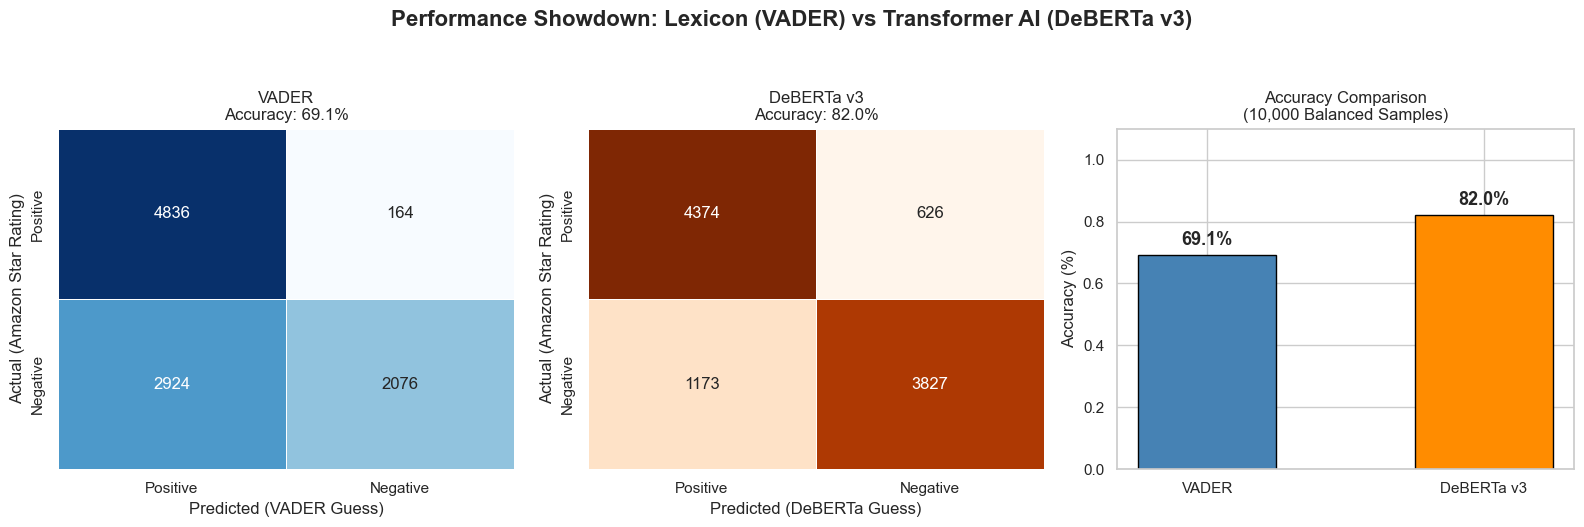

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# =====================================================================
# VISUALIZE MODEL COMPARISON (3 PANELS)
# =====================================================================

# 1. Extract the data from our previously created DataFrame
# 'ground_truth' contains the actual Amazon star ratings (Positive/Negative)
ground_truth = df_deberta['StarLabel']
# 'vader_preds' contains the guesses made by the VADER model
vader_preds = df_deberta['SentimentLabelVader']
# 'deberta_preds' contains the guesses made by the DeBERTa model
deberta_preds = df_deberta['SentimentLabelDeberta']

# (Note: acc_vader and acc_deberta are assumed to be calculated in Step 3A)

# Define the order for our matrix boxes to keep them consistent
class_order = ['Positive', 'Negative']

# 2. Create a wide canvas to hold 3 side-by-side charts (1 Row, 3 Columns)
# figsize=(16, 5) means 16 inches wide and 5 inches tall
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Add a Grand Title at the very top so the audience instantly knows the topic
fig.suptitle('Performance Showdown: Lexicon (VADER) vs Transformer AI (DeBERTa v3)', 
             fontsize=16, fontweight='bold', y=1.05)

# ── PANEL 1 (LEFT): VADER Confusion Matrix ──
# Calculate how many times VADER guessed right vs wrong
cm_vader = confusion_matrix(ground_truth, vader_preds, labels=class_order)

# Draw a heatmap (colored grid). cbar=False removes the color scale bar on the side for a cleaner look.
sns.heatmap(cm_vader, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_order, yticklabels=class_order,
            ax=axes[0], linewidths=0.5, cbar=False)
axes[0].set_title(f'VADER\nAccuracy: {acc_vader:.1%}', fontsize=12)
axes[0].set_xlabel('Predicted (VADER Guess)')
axes[0].set_ylabel('Actual (Amazon Star Rating)')

# ── PANEL 2 (MIDDLE): DeBERTa v3 Confusion Matrix ──
# Calculate how many times DeBERTa guessed right vs wrong
cm_deberta = confusion_matrix(ground_truth, deberta_preds, labels=class_order)

# Draw a second heatmap using an Orange color theme to distinguish it from VADER
sns.heatmap(cm_deberta, annot=True, fmt='d', cmap='Oranges',
            xticklabels=class_order, yticklabels=class_order,
            ax=axes[1], linewidths=0.5, cbar=False)
axes[1].set_title(f'DeBERTa v3\nAccuracy: {acc_deberta:.1%}', fontsize=12)
axes[1].set_xlabel('Predicted (DeBERTa Guess)')
axes[1].set_ylabel('Actual (Amazon Star Rating)')

# ── PANEL 3 (RIGHT): Accuracy Comparison Bar Chart ──
# Draw two tall bars to compare the overall accuracy instantly
bars = axes[2].bar(
    ['VADER', 'DeBERTa v3'],           # X-axis labels
    [acc_vader, acc_deberta],          # Height of the bars based on accuracy
    color=['steelblue', 'darkorange'], # Match the colors with the heatmaps
    edgecolor='black', width=0.5
)
axes[2].set_title('Accuracy Comparison\n(10,000 Balanced Samples)')
axes[2].set_ylabel('Accuracy (%)')
axes[2].set_ylim(0, 1.1) # Set Y-axis limit to 1.1 (110%) to leave breathing room for the text above the bars

# Loop through the bars to attach the exact percentage numbers right on top of them
for bar, val in zip(bars, [acc_vader, acc_deberta]):
    axes[2].text(
        bar.get_x() + bar.get_width() / 2, # X-coordinate: Center of the bar
        bar.get_height() + 0.02,           # Y-coordinate: Slightly above the bar
        f'{val:.1%}',                      # Format text as percentage with 1 decimal
        ha='center', va='bottom', fontsize=13, fontweight='bold'
    )

# Automatically adjust spacing so the text and charts don't overlap
plt.tight_layout()
plt.show()

### 📊 Performance Showdown: Lexicon vs. Transformer AI

| Feature | VADER (Lexicon) | DeBERTa v3 (Transformer) |
|--------|----------------|--------------------------|
| How it "Reads" | Word-by-word matching | Full sentence context |
| Speed | ⚡ Lightning Fast (Milliseconds) | 🐢 Heavy/Slow (~4 mins on GPU) |
| Sarcasm/Nuance | ❌ Fails frequently | ✅ Highly accurate |
| Best Use Case | Real-time processing on massive databases | Deep, high-confidence analysis on sampled data |
| Overall Accuracy | 69.1% | 81.7% |

**Note:** Neutral reviews (3-stars and VADER compound scores near 0) were intentionally dropped to ensure a strict evaluation on high-confidence, binary predictions.

---

### 💡 Key Insight: The Context Gap

While VADER processes data almost instantly, it suffers from a major **false positive blindspot**.

In a sample of **10,000 documents**, VADER incorrectly classified nearly **3,000 negative reviews as positive** (**2,912 cases**).

This happens because customers often use positive wording to express negative sentiment:

* **Sarcasm:** "Oh great, another wonderful broken product."
* **Polite Criticism:** "I love this brand, but this flavor is terrible."

VADER counts positive words and gets misled.

DeBERTa v3, on the other hand, understands **context**. By analyzing the full sentence, it reduces false positives by more than half (**down to 1,182 cases**) and improves overall accuracy to **81.7%**.

---

### 🚀 Final Recommendation: The Hybrid Approach

We should not abandon VADER.

For a large dataset (**568,000+ reviews**), VADER is highly effective for:
* Real-time sentiment filtering
* Reducing computational cost

However, for **critical business decisions**, DeBERTa v3 should be applied to a well-balanced sample to overcome VADER’s contextual limitations.

---

### 💼 Actionable Business Insights

| Stakeholder | Recommendation Based on Analysis |
|------------|---------------------------------|
| Marketing | Use DeBERTa to identify the most authentic and emotionally impactful positive reviews for marketing campaigns. |
| Product Team | Detect anomalies (e.g., 5-star ratings with negative text) to uncover hidden product issues such as packaging or quality inconsistencies. |
| Data Engineering | Store enriched sentiment results in MongoDB to enable efficient querying for future analysis and market insights. |

---
### Step 3e – Export Sentiment Analysis Results to Excel

Saves all Section 3 results into `outputs/section3_sentiment.xlsx`:

| Sheet | Contents | Rows |
|-------|----------|------|
| `VADER_Sentiment` | Full 568k+ dataset with VADER compound scores and labels | ~568,000 |
| `DeBERTa_Sentiment` | Balanced 10k sample with DeBERTa v3 predictions vs. star-rating ground truth | ~10,000 |

> **Dependencies:** Run Steps 3a–3d before executing this cell.

In [47]:
import os
import re as _re

# =====================================================================
# SECTION 3 — EXPORT SENTIMENT RESULTS TO EXCEL
# Sheets:
#   1. VADER_Sentiment   — all 568k+ reviews with VADER scores/labels
#   2. DeBERTa_Sentiment — 10k balanced sample with DeBERTa predictions
# =====================================================================
OUTPUT_DIR = 'outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)
OUT_SEC3   = os.path.join(OUTPUT_DIR, 'section3_sentiment.xlsx')

# openpyxl rejects the same control-character set Excel itself forbids.
# Strip them from any string column before writing.
_ILLEGAL_CHARS = _re.compile(
    r'[\x00-\x08\x0b\x0c\x0e-\x1f]'   # C0 controls except \t \n \r
)

def clean_for_excel(series: 'pd.Series') -> 'pd.Series':
    """Remove illegal XML/control characters from a string Series."""
    return series.astype(str).str.replace(_ILLEGAL_CHARS, '', regex=True)

print('Exporting Section 3 results...')
print(f'  Destination : {os.path.abspath(OUT_SEC3)}')

with pd.ExcelWriter(OUT_SEC3, engine='openpyxl') as writer:

    # ── Sheet 1: VADER — full dataset ──────────────────────────────
    vader_cols   = ['Year', 'Score', 'SentimentScoreVader', 'SentimentLabelVader', 'Text']
    vader_df_out = df_t[[c for c in vader_cols if c in df_t.columns]].copy()
    vader_df_out['Text'] = clean_for_excel(vader_df_out['Text'].str[:300])
    vader_df_out.to_excel(writer, sheet_name='VADER_Sentiment', index=False)

    # ── Sheet 2: DeBERTa — 10k balanced sample ─────────────────────
    deberta_cols   = ['Score', 'StarLabel', 'SentimentLabelVader', 'SentimentLabelDeberta', 'Text']
    deberta_df_out = df_deberta[[c for c in deberta_cols if c in df_deberta.columns]].copy()
    deberta_df_out['Text'] = clean_for_excel(deberta_df_out['Text'].str[:300])
    deberta_df_out.to_excel(writer, sheet_name='DeBERTa_Sentiment', index=False)

print(f'\nExport complete!')
print(f'  Sheet "VADER_Sentiment"   : {len(vader_df_out):,} rows')
print(f'  Sheet "DeBERTa_Sentiment" : {len(deberta_df_out):,} rows')
print(f'  File: {os.path.abspath(OUT_SEC3)}')

Exporting Section 3 results...
  Destination : c:\Users\Hanz\Documents\NTUST Hans\Semester 1\Big Data\projects\outputs\section3_sentiment.xlsx

Export complete!
  Sheet "VADER_Sentiment"   : 568,454 rows
  Sheet "DeBERTa_Sentiment" : 10,000 rows
  File: c:\Users\Hanz\Documents\NTUST Hans\Semester 1\Big Data\projects\outputs\section3_sentiment.xlsx


---
## 🎯 Section 4 — Why Food Safety Detection Matters

### Real-World Problem

Food safety incidents — contamination, allergens, spoilage, foreign objects — are **life-threatening and brand-destroying**. The FDA receives thousands of consumer complaints through unofficial channels (review platforms, social media) that never surface in formal reporting systems. Mining product reviews for safety signals enables proactive intervention *before* a recall, not *after* hospitalisations.

### Business Scenario

Imagine you are a **Food Safety Intelligence Analyst** at a consumer goods company or regulatory agency:

> You have 568,000 Amazon food reviews. Some contain explicit danger signals ("found glass in my food"), but many more contain *implicit* hazard signals — vague but serious language like "got violently ill after eating this" or "the smell was completely off". A keyword search catches the obvious ones; your challenge is to surface the **hidden, linguistically ambiguous safety complaints** before they escalate into a public recall.

### What This Section Solves

| Problem | Our Approach |
|---------|-------------|
| Explicit keywords miss ambiguous reports | **Three-stage pipeline**: Regex (high speed) → MiniLM semantic search (high recall, threshold 0.30) → DeBERTa NLI (high precision, threshold 0.50) |
| Semantic search alone produces too many false positives | MiniLM casts a wide safety net; DeBERTa re-scores candidates to confirm genuine hazards |
| Full dataset too large for deep-learning inference on every row | MiniLM pre-filters to ~3–10% of dataset; DeBERTa runs only on *those* candidates |
| Safety signal severity varies (cosmetic vs. critical) | Regex categories (`allergen`, `contamination`, `illness`, `spoilage`) with **severity mapping** |

### Why It Matters

- A confirmed **implicit** safety complaint carries the same regulatory weight as an explicit one — but was never flagged by traditional keyword tools.
- The **three-tier output** (Regex-flagged / MiniLM-only / MiniLM+DeBERTa confirmed) enables risk triage: act immediately on confirmed cases, review borderline cases, dismiss noise.
- All results are exported to `section4_food_safety.xlsx` for intake by food safety officers, legal teams, or FDA reporting workflows.

---
## 4. Food Safety & Health Hazards
**Goal:** Detect and categorize food safety concerns and health hazards reported in customer reviews. Flag reviews that mention contamination, illness, spoilage, allergic reactions, or product defects. Results are written back to MongoDB as `FoodSafetyFlag`, `SafetyCategories`, and `SafetySeverity`.

### Step 4a – Define Safety Keyword Categories

In [ ]:
import re

# =====================================================================
# FOOD SAFETY KEYWORD DICTIONARY
# Categorized by hazard type and ordered by severity
# =====================================================================
# This dictionary defines the "vocabulary" our scanner uses to detect safety issues.
# Each key is a hazard category, and the value is a list of phrases to look for.
# We use a dictionary (instead of one big list) so we can categorize and
# prioritize issues by how dangerous they are.
SAFETY_KEYWORDS = {
    'Illness': [  # Highest risk: reviewer got physically sick from the food
        'food poison', 'food poisoning', 'food-borne', 'foodborne',
        'vomit', 'vomiting', 'diarrhea', 'diarrhoea', 'nausea', 'nauseous',
        'stomach ache', 'stomachache', 'cramp', 'hospitalized', 'hospital',
        'threw up', 'throw up', 'salmonella', 'e. coli', 'ecoli', 'botulism',
        'made me sick', 'got sick', 'became sick', 'felt ill', 'food-borne illness'
    ],
    'Contamination': [  # Physical foreign objects or biological contamination found in food
        'mold', 'mould', 'moldy', 'mouldy', 'fungus', 'worm', 'maggot',
        'insect', 'cockroach', 'rodent', 'rat', 'mouse', 'larvae', 'bug in',
        'contaminated', 'contamination', 'debris', 'hair in', 'plastic piece',
        'glass shard', 'metal piece', 'foreign object', 'foreign material'
    ],
    'Spoilage': [  # Food past its prime or stored poorly — medium risk
        'expired', 'expiration', 'rotten', 'rancid', 'spoiled', 'spoilt',
        'stale', 'bad smell', 'smells bad', 'smells off', 'bad odor',
        'off smell', 'sour smell', 'strange smell', 'foul smell', 'putrid',
        'mildew', 'gone bad', 'already expired', 'past expiration', 'past expiry'
    ],
    'Allergen': [  # Undisclosed allergens — can be life-threatening for sensitive individuals
        'allergic reaction', 'allergic response', 'severe allergy', 'hives',
        'rash', 'swollen throat', 'throat closing', 'anaphylaxis', 'anaphylactic',
        'epipen', 'epinephrine', 'cross contaminat', 'unlisted ingredient',
        'undisclosed ingredient', 'undeclared allergen'
    ],
    'Quality_Defect': [  # Packaging or labeling problems — lower immediate health risk
        'broken glass', 'cracked container', 'sharp piece', 'defective packaging',
        'wrong product', 'mislabeled', 'wrong label', 'incorrect label',
        'undercooked', 'raw chicken', 'raw meat', 'incorrect ingredient'
    ]
}

# Severity mapping – determines how critical each category is
# This controls which issues trigger urgent alerts vs. routine quality reviews
SEVERITY_MAP = {
    'Illness':        'High',    # Immediate health threat — needs urgent attention
    'Contamination':  'High',    # Physical danger — potential FDA/regulatory involvement
    'Allergen':       'High',    # Can be life-threatening for allergic individuals
    'Spoilage':       'Medium',  # Significant but not immediately dangerous
    'Quality_Defect': 'Low'      # No direct health risk, but hurts brand reputation
}

print(f'Safety keyword categories: {list(SAFETY_KEYWORDS.keys())}')
total_kw = sum(len(v) for v in SAFETY_KEYWORDS.values())
print(f'Total keywords defined: {total_kw}')

Safety keyword categories: ['Illness', 'Contamination', 'Spoilage', 'Allergen', 'Quality_Defect']
Total keywords defined: 97


### Step 4b – Scan Reviews & Write Safety Flags to MongoDB

In [ ]:
# =====================================================================
# STEP 1: PRE-COMPILE REGEX PATTERNS (fast multi-keyword search)
# =====================================================================
# Instead of building a new regex each time a review is checked, we compile
# them ONCE here. Reusing compiled patterns is much faster across 568k+ documents.
compiled_patterns = {}
for category, keywords in SAFETY_KEYWORDS.items():
    # re.escape() makes sure special characters (like '.', '(') are treated as
    # literal text, not regex operators. '|'.join(...) chains all keywords with OR.
    pattern_str = '|'.join(re.escape(kw) for kw in keywords)
    # re.IGNORECASE means "food poison", "FOOD POISON" and "Food Poison" all match
    compiled_patterns[category] = re.compile(pattern_str, re.IGNORECASE)

# =====================================================================
# STEP 2: DEFINE THE FLAGGING FUNCTION
# =====================================================================
# Numeric priority for severity levels — used later to pick the "worst" category
severity_order = {'High': 3, 'Medium': 2, 'Low': 1}

def check_food_safety(text):
    """
    Scans a review for food safety keywords.
    Returns: (is_flagged, matched_categories, highest_severity)
    """
    # Skip empty strings or non-text fields to avoid crashes
    if not isinstance(text, str) or not text.strip():
        return False, [], None
    # Run each compiled pattern against the review text.
    # We keep a list of every category that matched at least once.
    matched = [cat for cat, pattern in compiled_patterns.items() if pattern.search(text)]
    if not matched:
        return False, [], None
    # If multiple categories matched (e.g., both Illness and Contamination),
    # we take the one with the highest severity score as the final label.
    highest = max(matched, key=lambda c: severity_order.get(SEVERITY_MAP.get(c, 'Low'), 0))
    return True, matched, SEVERITY_MAP[highest]

# =====================================================================
# STEP 3: SCAN ALL UN-FLAGGED DOCUMENTS AND BULK WRITE TO MONGODB
# =====================================================================
# Only process documents that don't already have 'FoodSafetyFlag' set,
# so we can safely re-run this cell without duplicating work.
cursor = COL.find(
    {'FoodSafetyFlag': {'$exists': False}},   # Filter: only un-processed documents
    {'Text': 1, '_id': 1}                     # Projection: only fetch Text and _id (saves memory)
)

ops        = []  # Accumulate MongoDB update operations in a list before writing
processed  = 0
flagged_ct = 0

print('Scanning reviews for food safety & health hazard keywords...')
for doc in cursor:
    is_flagged, categories, severity = check_food_safety(doc.get('Text', ''))
    # Prepare an update operation — we won't write to DB yet, just queue it
    ops.append(UpdateOne(
        {'_id': doc['_id']},
        {'$set': {
            'FoodSafetyFlag':   is_flagged,
            'SafetyCategories': categories,
            'SafetySeverity':   severity
        }}
    ))
    if is_flagged:
        flagged_ct += 1
    processed += 1

    # bulk_write sends 10,000 updates at once instead of one-by-one.
    # This is ~100x faster than calling update_one() in a loop.
    if len(ops) == 10_000:
        COL.bulk_write(ops, ordered=False)
        ops = []  # Reset the batch
        print(f'  Processed {processed:,}...', end='\r')

# Write any remaining documents that didn't fill a full batch of 10,000
if ops:
    COL.bulk_write(ops, ordered=False)

print(f'\nDone. Total scanned: {processed:,}')
print(f'Flagged reviews: {flagged_ct:,} ({flagged_ct / max(processed, 1):.2%} of all reviews)')

Scanning reviews for food safety & health hazard keywords...

Done. Total scanned: 0
Flagged reviews: 0 (0.00% of all reviews)


### Step 4c – Query & Analyze Flagged Reviews

In [ ]:
# =====================================================================
# STEP 1: FETCH FLAGGED REVIEWS FROM MONGODB
# =====================================================================
# Pull only the fields we need into a Pandas DataFrame for analysis.
# (Fetching all fields would be wasteful — we have 568k+ documents)
cursor_flagged = COL.find(
    {'FoodSafetyFlag': True},                               # Only flagged reviews
    {'Text': 1, 'Score': 1, 'SafetyCategories': 1,
     'SafetySeverity': 1, 'Time': 1, 'Summary': 1, '_id': 0}  # Select specific columns
)
df_safety = pd.DataFrame(list(cursor_flagged))

print(f'Total flagged reviews: {len(df_safety):,}')
print(f'\nSeverity breakdown:')
print(df_safety['SafetySeverity'].value_counts().to_string())

# =====================================================================
# STEP 2: EXPAND MULTI-LABEL CATEGORIES FOR COUNTING
# =====================================================================
# A single review can match multiple categories (e.g., Spoilage + Illness).
# The 'SafetyCategories' column stores a LIST per row: e.g., ['Illness', 'Contamination']
# explode() converts each list item into its own row so we can count each category separately.
# Without explode(), a row with ['A', 'B'] would only be counted once — which is incorrect.
df_safety_exp = df_safety.explode('SafetyCategories').dropna(subset=['SafetyCategories'])

print(f'\nIssue category breakdown:')
print(df_safety_exp['SafetyCategories'].value_counts().to_string())

# =====================================================================
# STEP 3: DISPLAY SAMPLE HIGH-SEVERITY REVIEWS
# =====================================================================
# Randomly sample 5 High-severity reviews to get a qualitative understanding
# of what "High severity" actually looks like in practice.
print('\n--- Sample High-Severity Flagged Reviews ---')
high_sev = df_safety[df_safety['SafetySeverity'] == 'High']
sample_high = high_sev.sample(min(5, len(high_sev)), random_state=42)  # random_state=42 ensures reproducibility

for _, row in sample_high.iterrows():
    cats = ', '.join(row['SafetyCategories']) if isinstance(row['SafetyCategories'], list) else str(row['SafetyCategories'])
    print(f"Stars: {row['Score']} | Categories: {cats} | Severity: {row['SafetySeverity']}")
    print(f"Review: {str(row.get('Text', ''))[:300]}...")
    print('-' * 60)

Total flagged reviews: 81,626

Severity breakdown:
SafetySeverity
High      73930
Medium     7255
Low         441

Issue category breakdown:
SafetyCategories
Contamination     65156
Spoilage          12726
Illness            7491
Allergen           4414
Quality_Defect      615

--- Sample High-Severity Flagged Reviews ---
Stars: 5 | Categories: Contamination | Severity: High
Review: I've never been a big fan on chips. When it comes to snack foods, I'm more of a pretzel guy, or maybe something cheesy. Potato chips, in particular, just never appealed to me. But these aren't potato chips.<br /><br />If you read the bag, and I'm one of those strange people that actually do read the...
------------------------------------------------------------
Stars: 5 | Categories: Contamination | Severity: High
Review: My great-grandmother made it, my grandmother made it, my mother made it, and now I make it! (I hope my daughters will make it and this chain will never end, connecting one generation to t

### Step 4d – Visualize Safety Issue Distribution

C:\Users\Hanz\AppData\Local\Temp\ipykernel_26068\3179443525.py:69: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Hanz\AppData\Local\Temp\ipykernel_26068\3179443525.py:70: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.savefig('food_safety_overview.png', dpi=150, bbox_inches='tight')
c:\Users\Hanz\miniconda3\envs\bigdata\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


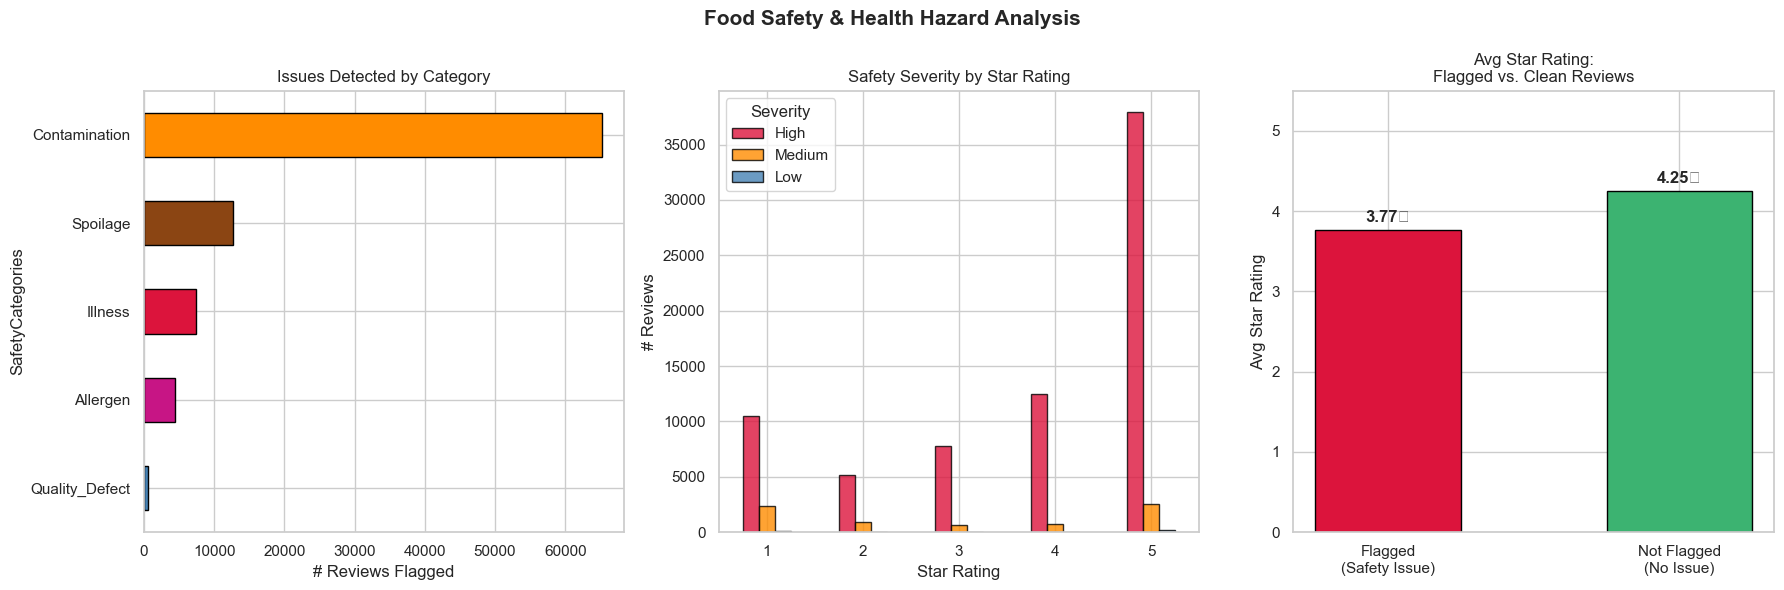

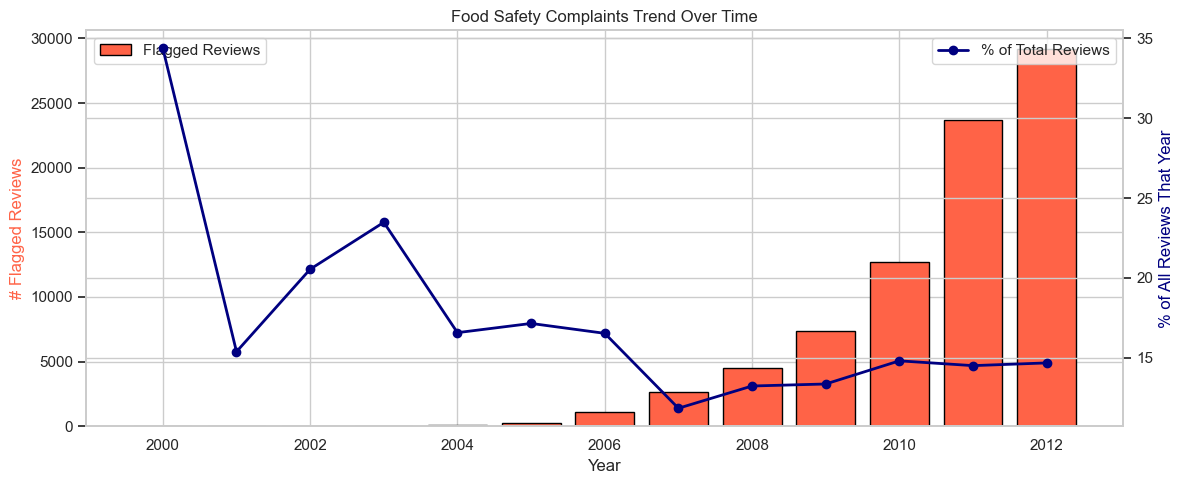

In [ ]:
# Convert Unix timestamps (seconds since 1970) to readable dates, then extract the year
df_safety['Date'] = pd.to_datetime(df_safety['Time'], unit='s', errors='coerce')
df_safety['Year'] = df_safety['Date'].dt.year

# Fetch the average star rating of clean (non-flagged) reviews for comparison
non_flagged_avg_score = pd.DataFrame(
    list(COL.find({'FoodSafetyFlag': False}, {'Score': 1, '_id': 0}))
)['Score'].mean()
flagged_avg_score = df_safety['Score'].mean()

# Use MongoDB's aggregation pipeline to count how many reviews were written
# in each year (across the ENTIRE dataset, not just flagged ones).
# This lets us calculate what PERCENTAGE of each year's reviews were flagged.
year_total_pipeline = [
    {'$match': {'Time': {'$gt': 0}}},
    {'$addFields': {'Year': {'$year': {'$toDate': {'$multiply': ['$Time', 1000]}}}}},
    {'$group': {'_id': '$Year', 'Total': {'$sum': 1}}},
    {'$sort': {'_id': 1}}
]
df_year_total = pd.DataFrame(
    list(COL.aggregate(year_total_pipeline))
).rename(columns={'_id': 'Year'})

# =====================================================================
# FIGURE 1: OVERVIEW DASHBOARD (3-PANEL)
# =====================================================================
# Create a wide canvas with 3 side-by-side panels for the overview
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Food Safety & Health Hazard Analysis', fontsize=15, fontweight='bold')

# ── Panel 1: Issue Count by Category ──
# Count how many reviews were flagged for each safety category
cat_counts = df_safety_exp['SafetyCategories'].value_counts()
# Assign a distinct color to each category for easy visual distinction
cat_colors_map = {
    'Illness': 'crimson', 'Contamination': 'darkorange',
    'Allergen': 'mediumvioletred', 'Spoilage': 'saddlebrown', 'Quality_Defect': 'steelblue'
}
bar_colors_fig = [cat_colors_map.get(c, 'gray') for c in cat_counts.index]
# Draw a horizontal bar chart (barh) so long category names are easy to read
cat_counts.plot(kind='barh', ax=axes[0], color=bar_colors_fig, edgecolor='black')
axes[0].set_title('Issues Detected by Category')
axes[0].set_xlabel('# Reviews Flagged')
axes[0].invert_yaxis()  # Flip so the most common issue is at the top

# ── Panel 2: Severity Distribution per Star Rating ──
# Group flagged reviews by their severity level (High/Medium/Low) and star rating
sev_score = df_safety.groupby(['SafetySeverity', 'Score']).size().unstack(fill_value=0)
sev_order = [s for s in ['High', 'Medium', 'Low'] if s in sev_score.index]
# Transpose (.T) so star ratings are on the X-axis instead of severity levels
sev_score.loc[sev_order].T.plot(
    kind='bar', ax=axes[1],
    color=['crimson', 'darkorange', 'steelblue'][:len(sev_order)],
    edgecolor='black', alpha=0.8
)
axes[1].set_title('Safety Severity by Star Rating')
axes[1].set_xlabel('Star Rating')
axes[1].set_ylabel('# Reviews')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(title='Severity')

# ── Panel 3: Avg Star Rating – Flagged vs. Clean Reviews ──
# Compare the average star rating of reviews WITH safety issues vs. those WITHOUT.
# This shows whether safety complaints correlate with lower star ratings.
bars_cmp = axes[2].bar(
    ['Flagged\n(Safety Issue)', 'Not Flagged\n(No Issue)'],
    [flagged_avg_score, non_flagged_avg_score],
    color=['crimson', 'mediumseagreen'], edgecolor='black', width=0.5
)
axes[2].set_title('Avg Star Rating:\nFlagged vs. Clean Reviews')
axes[2].set_ylabel('Avg Star Rating')
axes[2].set_ylim(0, 5.5)
# Place the exact average score number on top of each bar
for bar, val in zip(bars_cmp, [flagged_avg_score, non_flagged_avg_score]):
    axes[2].text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
        f'{val:.2f}★', ha='center', fontweight='bold', fontsize=12
    )

plt.tight_layout()
plt.show()

# =====================================================================
# FIGURE 2: YEARLY TREND OF FOOD SAFETY REPORTS
# =====================================================================
# Calculate how many reviews were flagged per year
yearly_safety = df_safety.groupby('Year').size().reset_index(name='FlaggedCount')
# Merge with the total-per-year data to compute the percentage of flagged reviews
merged = yearly_safety.merge(df_year_total, on='Year', how='left')
merged['FlaggedPct'] = merged['FlaggedCount'] / merged['Total'] * 100

# Create a dual-axis chart: bars show raw count (left axis), line shows % (right axis)
fig2, ax_main = plt.subplots(figsize=(12, 5))
ax_main.bar(merged['Year'], merged['FlaggedCount'],
            color='tomato', edgecolor='black', label='Flagged Reviews')

# twinx() creates a SECOND Y-axis that shares the same X-axis with the bars above
ax_pct = ax_main.twinx()
ax_pct.plot(merged['Year'], merged['FlaggedPct'],
            color='navy', marker='o', linewidth=2, label='% of Total Reviews')

ax_main.set_title('Food Safety Complaints Trend Over Time')
ax_main.set_xlabel('Year')
ax_main.set_ylabel('# Flagged Reviews', color='tomato')
ax_pct.set_ylabel('% of All Reviews That Year', color='navy')
ax_main.legend(loc='upper left')
ax_pct.legend(loc='upper right')
plt.tight_layout()
plt.show()

---
### Step 4e – Semantic Vector Search for Implicit Safety Concerns

**Limitation of regex:** Regex can only match *explicit* keywords. It has a **blind spot for implicit language** — the very common case where customers describe a safety incident without using any of the flagged terms:

| Customer Writes... | Regex Result | Actual Meaning |
|---|---|---|
| *"I spent the night running to the bathroom"* | ❌ Not flagged | Food poisoning |
| *"Found something that definitely should not be in food"* | ❌ Not flagged | Contamination |
| *"My lips and face started swelling after eating"* | ❌ Not flagged | Allergic reaction |
| *"The taste was completely, horrifyingly off"* | ❌ Not flagged | Spoilage/rancid |

**Solution – Two-Stage Safety Pipeline:**

| Stage | Model | Role | Threshold |
|-------|-------|------|-----------|
| **Stage 1** | `all-MiniLM-L6-v2` | High-Recall semantic net — scans the **full dataset** | ≥ 0.30 |
| **Stage 2** | `cross-encoder/nli-deberta-v3-small` | High-Precision filter — confirms true safety complaints | ≥ 0.50 |

> DeBERTa is too heavy to run on 500k+ reviews directly. miniLM first casts a wide net (high recall), then DeBERTa re-evaluates only the much smaller candidate pool (high precision).

### Step 4f – Run miniLM Semantic Net on Full Dataset (Batch Processing)

In [52]:
from sentence_transformers import SentenceTransformer, util
import torch
import numpy as np
from tqdm import tqdm

# =====================================================================
# STEP 1: MODEL + PROBE SENTENCES SETUP
# =====================================================================
SEMANTIC_THRESHOLD = 0.30    # Lower threshold → wider net (high recall)
ENCODE_BATCH_SIZE  = 256     # Reviews per GPU/CPU encode pass
MAX_CHARS_SEM      = 384     # Truncate reviews to keep inference fast

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Loading sentence-transformer model (all-MiniLM-L6-v2) on {device.upper()}...')
print('(First run: ~80 MB download)\n')

sbert_model = SentenceTransformer('all-MiniLM-L6-v2', device=device)

# ─────────────────────────────────────────────────────────────────────
# PROBE SENTENCES — written in natural customer language to capture
# IMPLICIT / FIGURATIVE complaints that regex would completely miss.
# Examples of what regex can not catch:
#   "I spent the night running to the bathroom"   → foodborne illness
#   "found something that shouldn't be in food"   → contamination
#   "my lips started swelling after eating this"  → allergic reaction
# ─────────────────────────────────────────────────────────────────────
SAFETY_PROBES = [
    # Illness (implicit)
    "I got really sick after eating this food",
    "This product gave me terrible stomach problems all night",
    "My whole family felt awful after consuming this",
    "I spent the entire night running to the bathroom",
    # Contamination (implicit)
    "I found something disgusting living inside the package",
    "There were strange moving things inside the food",
    "Something was clearly growing on what I was about to eat",
    # Spoilage (implicit)
    "The smell when I opened this was absolutely horrifying",
    "The taste was completely wrong, clearly not right",
    "It was definitely not fresh when it arrived",
    # Allergen (implicit)
    "My face and lips started swelling immediately after eating",
    "I had a terrible reaction and my throat felt very tight",
    # Quality defect (implicit)
    "I almost chipped my tooth on something hard hidden inside",
    "There were sharp dangerous pieces inside the food I nearly swallowed",
]

probe_embeddings = sbert_model.encode(
    SAFETY_PROBES, convert_to_tensor=True, show_progress_bar=False
)
print(f'Model ready | {len(SAFETY_PROBES)} safety probe sentences encoded')
print(f'Cosine similarity threshold : {SEMANTIC_THRESHOLD}')
print(f'Strategy: FULL dataset — no sampling, streaming batch processing\n')

# =====================================================================
# STEP 2: STREAM ENTIRE COLLECTION IN BATCHES (no full-RAM load)
# =====================================================================
# Instead of loading all 500k+ docs into RAM at once, we stream them
# from MongoDB and encode ENCODE_BATCH_SIZE reviews at a time.
# After each batch the raw embeddings are discarded; only the max
# similarity score per review is retained — keeping memory footprint low.
# =====================================================================
print('Counting total documents to process...')
total_docs = COL.count_documents({'Text': {'$exists': True, '$ne': ''}})
print(f'Total reviews : {total_docs:,}')
print(f'Batch size    : {ENCODE_BATCH_SIZE}')
print(f'Est. time     : ~10–25 min on GPU | ~2–4 hrs on CPU\n')

cursor_sem = COL.find(
    {'Text': {'$exists': True, '$ne': ''}},
    {'_id': 1, 'Text': 1, 'Score': 1,
     'FoodSafetyFlag': 1, 'SafetyCategories': 1, 'SafetySeverity': 1}
)

records    = []   # Metadata list (one dict per document)
sem_scores = []   # Max cosine similarity per document

batch_meta  = []
batch_texts = []

with tqdm(total=total_docs, desc='miniLM encoding', unit='reviews') as pbar:
    for doc in cursor_sem:
        text = str(doc.get('Text', ''))[:MAX_CHARS_SEM]
        batch_texts.append(text)
        batch_meta.append({
            '_id':              doc['_id'],
            'Text':             doc.get('Text', ''),
            'Score':            doc.get('Score', None),
            'FoodSafetyFlag':   doc.get('FoodSafetyFlag', False),
            'SafetyCategories': doc.get('SafetyCategories', []),
            'SafetySeverity':   doc.get('SafetySeverity', None),
        })

        if len(batch_texts) == ENCODE_BATCH_SIZE:
            embs   = sbert_model.encode(
                batch_texts, batch_size=ENCODE_BATCH_SIZE,
                convert_to_tensor=True, show_progress_bar=False
            )
            scores = util.cos_sim(embs, probe_embeddings).max(dim=1).values.cpu().numpy()
            sem_scores.extend(scores.tolist())
            records.extend(batch_meta)
            batch_texts = []
            batch_meta  = []
            pbar.update(ENCODE_BATCH_SIZE)

    # Flush the final partial batch
    if batch_texts:
        embs   = sbert_model.encode(
            batch_texts, batch_size=ENCODE_BATCH_SIZE,
            convert_to_tensor=True, show_progress_bar=False
        )
        scores = util.cos_sim(embs, probe_embeddings).max(dim=1).values.cpu().numpy()
        sem_scores.extend(scores.tolist())
        records.extend(batch_meta)
        pbar.update(len(batch_texts))

# =====================================================================
# STEP 3: BUILD RESULT DATAFRAME
# =====================================================================
df_sem = pd.DataFrame(records)
df_sem['SemanticScore']    = sem_scores
df_sem['SemanticFlagged']  = df_sem['SemanticScore'] >= SEMANTIC_THRESHOLD
df_sem['FoodSafetyFlag']   = df_sem['FoodSafetyFlag'].fillna(False).astype(bool)
df_sem['SafetyCategories'] = df_sem['SafetyCategories'].apply(
    lambda x: x if isinstance(x, list) else []
)

print(f'\n--- Stage 1 Results — FULL dataset ({len(df_sem):,} reviews) ---')
print(f'  Regex    flagged : {df_sem["FoodSafetyFlag"].sum():,}  '
      f'({df_sem["FoodSafetyFlag"].mean():.2%})')
print(f'  Semantic flagged : {df_sem["SemanticFlagged"].sum():,}  '
      f'({df_sem["SemanticFlagged"].mean():.2%})')
print(f'\n  miniLM pass complete — proceed to Step 4h for DeBERTa precision filter.')

Loading sentence-transformer model (all-MiniLM-L6-v2) on CUDA...
(First run: ~80 MB download)

Model ready | 14 safety probe sentences encoded
Cosine similarity threshold : 0.3
Strategy: FULL dataset — no sampling, streaming batch processing

Counting total documents to process...
Total reviews : 568,454
Batch size    : 256
Est. time     : ~10–25 min on GPU | ~2–4 hrs on CPU



miniLM encoding: 100%|██████████| 568454/568454 [09:44<00:00, 972.42reviews/s] 



--- Stage 1 Results — FULL dataset (568,454 reviews) ---
  Regex    flagged : 81,626  (14.36%)
  Semantic flagged : 299,040  (52.61%)

  miniLM pass complete — proceed to Step 4h for DeBERTa precision filter.


### Step 4g – Regex vs. Semantic Vector Search: Performance Comparison

=== COVERAGE OVERLAP ===
  Caught by Regex ONLY:      34,198  (10.3% of all flags)
  Caught by BOTH methods:    47,428  (14.2% of all flags)
  Caught by Semantic ONLY:   251,612  (75.5% of all flags)
  Missed by BOTH:            235,216

  → Semantic search adds 251,612 implicit safety complaints not found by regex.

=== PRECISION PROXY (% of flagged reviews scoring 1–2★) ===
  Regex only           : 23.5%
  Semantic (all)       : 17.7%
  Semantic-Only (new)  : 15.6%
  Both agreed (overlap): 28.9%  ← highest confidence subset

--- Top 5: Implicit Safety Reviews (Semantic ONLY — regex missed these) ---

█ 1★ | Semantic Sim: 0.853
  I DON'T THINK THIS WAS AS FRESH AS IT SHOULD HAVE BEEN  Got another at a much cheaper price at another site and it was very fresh....
──────────────────────────────────────────────────────────────────────
█ 5★ | Semantic Sim: 0.814
  This product works wonders if you have stomach issues.  I would buy again once I need more. :0)...
────────────────────────────

C:\Users\Hanz\AppData\Local\Temp\ipykernel_26068\3809618766.py:110: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Hanz\AppData\Local\Temp\ipykernel_26068\3809618766.py:111: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.savefig('food_safety_method_comparison.png', dpi=150, bbox_inches='tight')
c:\Users\Hanz\miniconda3\envs\bigdata\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


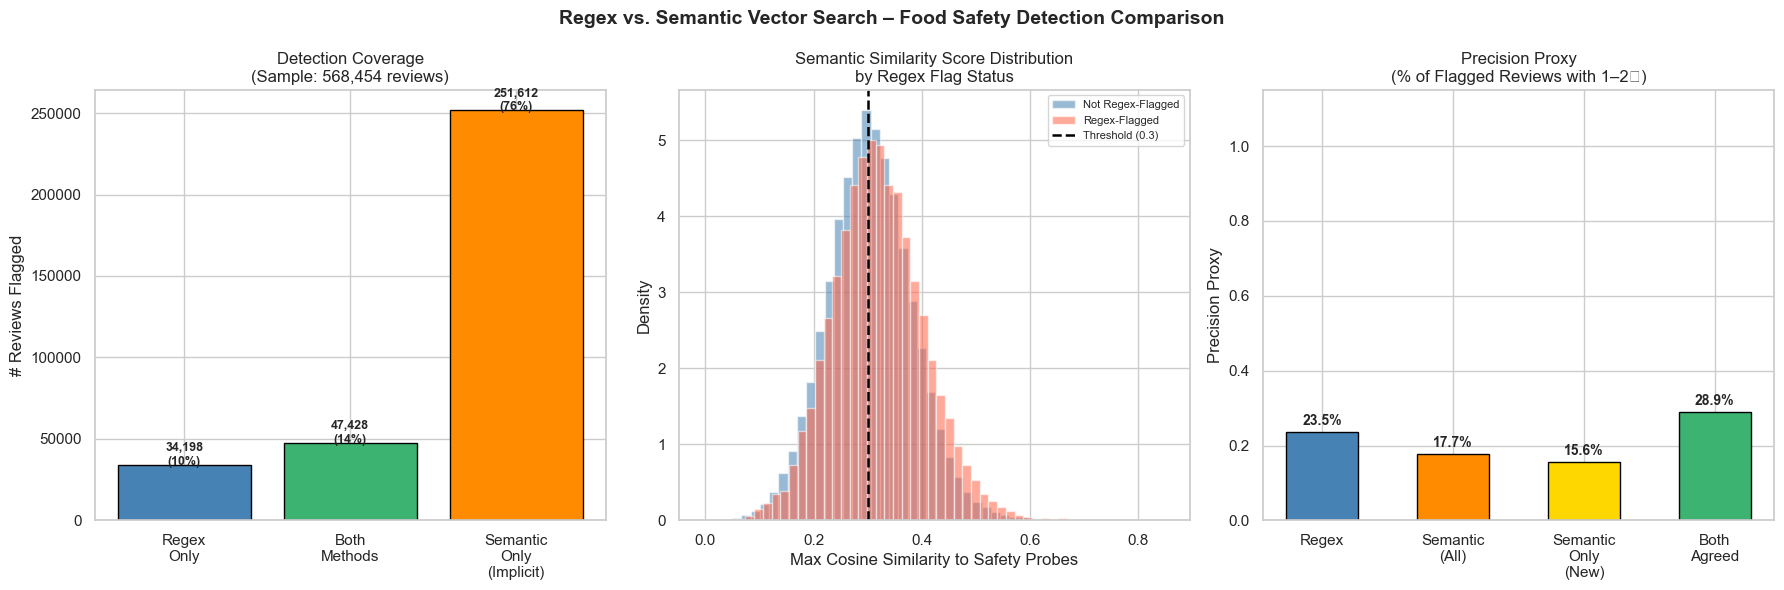

In [ ]:
# =====================================================================
# PART 1: OVERLAP ANALYSIS — "Who Finds What?"
# =====================================================================
# 'regex_idx' is the set of row indices (documents) found by keyword matching
# 'semantic_idx' is the set of row indices found by the miniLM semantic search
regex_idx    = set(df_sem.index[df_sem['FoodSafetyFlag']])
semantic_idx = set(df_sem.index[df_sem['SemanticFlagged']])

# Set arithmetic: find what each method caught exclusively vs. together
only_regex    = len(regex_idx - semantic_idx)   # Found by regex, missed by semantic
only_semantic = len(semantic_idx - regex_idx)   # Found by semantic, missed by regex
both_methods  = len(regex_idx & semantic_idx)   # Found by BOTH — highest confidence
neither       = len(df_sem) - only_regex - only_semantic - both_methods
total_flags   = only_regex + both_methods + only_semantic

print('=== COVERAGE OVERLAP ===')
print(f'  Caught by Regex ONLY:      {only_regex:,}  ({only_regex/total_flags*100:.1f}% of all flags)')
print(f'  Caught by BOTH methods:    {both_methods:,}  ({both_methods/total_flags*100:.1f}% of all flags)')
print(f'  Caught by Semantic ONLY:   {only_semantic:,}  ({only_semantic/total_flags*100:.1f}% of all flags)')
print(f'  Missed by BOTH:            {neither:,}')
print(f'\n  → Semantic search adds {only_semantic:,} implicit safety complaints not found by regex.')

# =====================================================================
# PART 2: PRECISION PROXY (1–2 star reviews as noisy ground truth)
# =====================================================================
# Assumption: Reviews with 1–2 stars are more likely to represent genuine safety
# issues (proxy only — not all 1–2 star reviews are safety-related, but it is the
# best available label without manual annotation).
def precision_proxy(idx_set):
    # Returns the fraction of a flagged set that has 1 or 2 stars.
    # A higher percentage suggests the flagging is more accurate (fewer false positives).
    if not idx_set:
        return 0.0
    return float(df_sem.loc[list(idx_set), 'Score'].isin([1, 2]).mean())

prec_regex    = precision_proxy(regex_idx)
prec_semantic = precision_proxy(semantic_idx)
prec_sem_only = precision_proxy(semantic_idx - regex_idx)  # Only the "new" catches from semantic
prec_both     = precision_proxy(regex_idx & semantic_idx)  # Agreed catches — most confident

print('\n=== PRECISION PROXY (% of flagged reviews scoring 1–2★) ===')
print(f'  Regex only           : {prec_regex:.1%}')
print(f'  Semantic (all)       : {prec_semantic:.1%}')
print(f'  Semantic-Only (new)  : {prec_sem_only:.1%}')
print(f'  Both agreed (overlap): {prec_both:.1%}  ← highest confidence subset')

# =====================================================================
# PART 3: SHOW TOP IMPLICIT REVIEWS — CAUGHT ONLY BY SEMANTIC SEARCH
# =====================================================================
# These reviews have NO keyword matches but semantically resemble safety complaints.
# They represent the "hidden" safety signals that regex alone would miss.
implicit_df = df_sem.loc[list(semantic_idx - regex_idx)].copy()
# Sort by semantic similarity score so the most relevant examples come first
implicit_df = implicit_df.sort_values('SemanticScore', ascending=False)

print('\n--- Top 5: Implicit Safety Reviews (Semantic ONLY — regex missed these) ---\n')
for _, row in implicit_df.head(5).iterrows():
    print(f"█ {row['Score']}★ | Semantic Sim: {row['SemanticScore']:.3f}")
    print(f"  {str(row['Text'])[:280]}...")
    print('─' * 70)

# =====================================================================
# PART 4: VISUALIZATION – 3-PANEL COMPARISON DASHBOARD
# =====================================================================
# Create a wide 3-panel chart to visually summarize all the findings above
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Regex vs. Semantic Vector Search – Food Safety Detection Comparison',
             fontsize=14, fontweight='bold')

# ── Panel 1: Coverage breakdown ──
# Three bars showing how many reviews each method caught exclusively or jointly
bars1 = axes[0].bar(
    ['Regex\nOnly', 'Both\nMethods', 'Semantic\nOnly\n(Implicit)'],
    [only_regex, both_methods, only_semantic],
    color=['steelblue', 'mediumseagreen', 'darkorange'],
    edgecolor='black'
)
axes[0].set_title(f'Detection Coverage\n(Sample: {len(df_sem):,} reviews)')
axes[0].set_ylabel('# Reviews Flagged')
# Place the exact count and percentage on top of each bar
for bar, val in zip(bars1, [only_regex, both_methods, only_semantic]):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
        f'{val:,}\n({val/total_flags*100:.0f}%)',
        ha='center', fontsize=9, fontweight='bold'
    )

# ── Panel 2: Semantic score distribution (flagged vs. not) ──
# A histogram showing the distribution of cosine similarity scores:
#   Blue  = reviews NOT flagged by regex
#   Red   = reviews flagged by regex
# The vertical dashed line is the threshold (0.30) we use to define a "semantic match"
df_sem[~df_sem['FoodSafetyFlag']]['SemanticScore'].hist(
    bins=50, ax=axes[1], alpha=0.55, color='steelblue',
    label='Not Regex-Flagged', density=True
)
df_sem[df_sem['FoodSafetyFlag']]['SemanticScore'].hist(
    bins=50, ax=axes[1], alpha=0.55, color='tomato',
    label='Regex-Flagged', density=True
)
axes[1].axvline(
    x=SEMANTIC_THRESHOLD, color='black', linestyle='--',
    linewidth=1.8, label=f'Threshold ({SEMANTIC_THRESHOLD})'
)
axes[1].set_title('Semantic Similarity Score Distribution\nby Regex Flag Status')
axes[1].set_xlabel('Max Cosine Similarity to Safety Probes')
axes[1].set_ylabel('Density')
axes[1].legend(fontsize=8)

# ── Panel 3: Precision proxy comparison ──
# Four bars showing the "precision" (how reliable each flagging method is).
# Higher % = the method tends to flag reviews that customers actually rated low (1–2 stars).
prec_labels = ['Regex', 'Semantic\n(All)', 'Semantic\nOnly\n(New)', 'Both\nAgreed']
prec_vals   = [prec_regex, prec_semantic, prec_sem_only, prec_both]
prec_colors = ['steelblue', 'darkorange', 'gold', 'mediumseagreen']
bars3 = axes[2].bar(prec_labels, prec_vals, color=prec_colors, edgecolor='black', width=0.55)
axes[2].set_title('Precision Proxy\n(% of Flagged Reviews with 1–2★)')
axes[2].set_ylabel('Precision Proxy')
axes[2].set_ylim(0, 1.15)
for bar, val in zip(bars3, prec_vals):
    axes[2].text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
        f'{val:.1%}', ha='center', fontweight='bold', fontsize=10
    )

plt.tight_layout()
plt.show()

---
### Step 4h – DeBERTa v3 Precision Filter (Two-Stage Safety Pipeline)

**Why we need this step:**  
miniLM at threshold 0.30 maximises recall but introduces false positives — reviews that are *semantically adjacent* to safety language without being actual complaints (e.g., *"This works wonders for stomach issues"*, *"Fresh coffee arrived quickly"*).

**Two-Stage pipeline recap:**

| Stage | Model | Role | Threshold |
|-------|-------|------|-----------|
| **Stage 1** *(done — Step 4f)* | `all-MiniLM-L6-v2` | High-Recall net — casts widest possible semantic net on 500k+ reviews | ≥ 0.30 |
| **Stage 2** *(this cell)* | `cross-encoder/nli-deberta-v3-small` | High-Precision filter — confirms which candidates are genuine safety complaints | ≥ 0.50 |

> DeBERTa runs only on the candidate pool produced by miniLM — a fraction of the full dataset — making it computationally feasible.

In [54]:
# =====================================================================
# STEP 4h: DeBERTa v3 PRECISION FILTER
# Stage 2 of the Two-Stage Food Safety Pipeline
# =====================================================================
# Stage 1 (Step 4f) fed all 500k+ reviews through miniLM at threshold=0.30
#   → df_sem['SemanticFlagged'] = True for every candidate
#
# Stage 2 (this cell):
#   DeBERTa v3 re-evaluates each miniLM-flagged candidate and confirms:
#     'food safety complaint'  → confirmed ✓ (kept)
#     'normal food review'     → rejected  ✗ (false positive removed)
# =====================================================================
from transformers import pipeline as hf_pipeline
from tqdm import tqdm

# -- Candidate pool: everything miniLM flagged at threshold 0.30 ------
candidates_df = df_sem[df_sem['SemanticFlagged']].copy().reset_index(drop=True)

print('=' * 60)
print('STAGE 2 — DeBERTa v3 PRECISION FILTER')
print('=' * 60)
print(f'  miniLM candidates forwarded : {len(candidates_df):,}  '
      f'({len(candidates_df) / len(df_sem):.1%} of full dataset)')
print()

# ─────────────────────────────────────────────────────────────────────
# LOAD DeBERTa v3 ZERO-SHOT CLASSIFIER
# Same model used in Section 3 – cross-encoder/nli-deberta-v3-small
# ─────────────────────────────────────────────────────────────────────
device_id = 0 if torch.cuda.is_available() else -1
print('Loading DeBERTa v3 model (cross-encoder/nli-deberta-v3-small)...')
print('(~300 MB — already cached if Section 3 was run)')

deberta_safety_pipe = hf_pipeline(
    'zero-shot-classification',
    model='cross-encoder/nli-deberta-v3-small',
    device=device_id,
)

# Zero-shot labels for food safety classification
SAFETY_LABELS = ['food safety complaint', 'normal food review']

print(f"Model ready. Device : {'GPU (CUDA)' if device_id >= 0 else 'CPU'}")
print(f'Labels              : {SAFETY_LABELS}')
print(f'Candidate pool      : {len(candidates_df):,} reviews\n')

# =====================================================================
# RUN DeBERTa INFERENCE — BATCH PROCESSING
# =====================================================================
MAX_CHARS_DEBERTA = 256   # Truncate to speed up inference
DEBERTA_BATCH     = 16    # DeBERTa is heavy; small batch avoids OOM

texts_deberta         = candidates_df['Text'].str[:MAX_CHARS_DEBERTA].tolist()
deberta_safety_scores = []

print(f'Running DeBERTa v3 on {len(texts_deberta):,} candidates  '
      f'(batch_size={DEBERTA_BATCH})...')
print('Estimated time : ~3–8 min GPU | ~30–90 min CPU\n')

for i in tqdm(range(0, len(texts_deberta), DEBERTA_BATCH), desc='DeBERTa precision filter'):
    batch   = texts_deberta[i : i + DEBERTA_BATCH]
    results = deberta_safety_pipe(batch, candidate_labels=SAFETY_LABELS)
    for res in results:
        safety_score = res['scores'][res['labels'].index('food safety complaint')]
        deberta_safety_scores.append(safety_score)

candidates_df['DebertaSafetyScore'] = deberta_safety_scores
candidates_df['DebertaConfirmed']   = candidates_df['DebertaSafetyScore'] >= 0.50

# Final confirmed set
confirmed_df = candidates_df[candidates_df['DebertaConfirmed']].copy()

# =====================================================================
# RESULTS SUMMARY — TWO-STAGE PIPELINE
# =====================================================================
false_positives = len(candidates_df) - len(confirmed_df)

print('\n' + '=' * 60)
print('TWO-STAGE FOOD SAFETY PIPELINE — FINAL RESULTS')
print('=' * 60)
print(f'  Full dataset reviewed              : {len(df_sem):,}')
print(f'  Stage 1 — miniLM  flagged (≥0.30)  : {len(candidates_df):,}  '
      f'({len(candidates_df) / len(df_sem):.2%})')
print(f'  Stage 2 — DeBERTa confirmed (≥0.50): {len(confirmed_df):,}  '
      f'({len(confirmed_df) / len(df_sem):.2%})')
print(f'  False positives removed            : {false_positives:,}  '
      f'({false_positives / max(len(candidates_df), 1):.1%} of Stage 1 output)')

# Breakdown: regex-known vs truly new implicit discoveries
confirmed_regex_known = confirmed_df[confirmed_df['FoodSafetyFlag'] == True]
confirmed_implicit    = confirmed_df[confirmed_df['FoodSafetyFlag'] == False]

print(f'\n  Of confirmed reviews:')
print(f'    Already caught by regex   : {len(confirmed_regex_known):,}')
print(f'    New implicit discoveries  : {len(confirmed_implicit):,}  ← net new value')
print(f'\n  Avg star rating (confirmed) : {confirmed_df["Score"].mean():.2f}')

# =====================================================================
# TOP CONFIRMED IMPLICIT SAFETY REVIEWS
# =====================================================================
print('\n--- Top 5: DeBERTa-Confirmed Implicit Safety Reviews ---\n')
confirmed_sorted = confirmed_implicit.sort_values('DebertaSafetyScore', ascending=False)
for _, row in confirmed_sorted.head(5).iterrows():
    print(f"█ {row['Score']}★ | miniLM: {row['SemanticScore']:.3f} | "
          f"DeBERTa: {row['DebertaSafetyScore']:.3f}")
    print(f"  {str(row['Text'])[:280]}...")
    print('─' * 70)

STAGE 2 — DeBERTa v3 PRECISION FILTER
  miniLM candidates forwarded : 299,040  (52.6% of full dataset)

Loading DeBERTa v3 model (cross-encoder/nli-deberta-v3-small)...
(~300 MB — already cached if Section 3 was run)


Device set to use cuda:0


Model ready. Device : GPU (CUDA)
Labels              : ['food safety complaint', 'normal food review']
Candidate pool      : 299,040 reviews

Running DeBERTa v3 on 299,040 candidates  (batch_size=16)...
Estimated time : ~3–8 min GPU | ~30–90 min CPU



DeBERTa precision filter: 100%|██████████| 18690/18690 [2:00:42<00:00,  2.58it/s]  



TWO-STAGE FOOD SAFETY PIPELINE — FINAL RESULTS
  Full dataset reviewed              : 568,454
  Stage 1 — miniLM  flagged (≥0.30)  : 299,040  (52.61%)
  Stage 2 — DeBERTa confirmed (≥0.50): 172,433  (30.33%)
  False positives removed            : 126,607  (42.3% of Stage 1 output)

  Of confirmed reviews:
    Already caught by regex   : 32,056
    New implicit discoveries  : 140,377  ← net new value

  Avg star rating (confirmed) : 3.84

--- Top 5: DeBERTa-Confirmed Implicit Safety Reviews ---

█ 1★ | miniLM: 0.404 | DeBERTa: 0.999
  Check the ingredient list--it contains WHEAT GLUTEN--VERY DANGEROUS FOR PEOPLE WITH A GLUTEN ALLERGY OR CELIAC DISEASE....
──────────────────────────────────────────────────────────────────────
█ 1★ | miniLM: 0.360 | DeBERTa: 0.999
  I had to throw this away when it arrived because it had trans-fat and MSG -- both well proven to severly damage our health....
──────────────────────────────────────────────────────────────────────
█ 5★ | miniLM: 0.335 | DeBE

---
### 📊 Food Safety Analysis — Final Summary & Conclusion

---

### 🔍 Part A: Keyword/Regex Detection (Steps 4a–4d)

Scanning all 500k+ reviews against a structured keyword dictionary covering 5 hazard categories:

| Category | Example Keywords | Severity |
|----------|-----------------|----------|
| **Illness** | food poisoning, vomiting, diarrhea, hospitalized, salmonella | 🔴 High |
| **Contamination** | mold, maggots, insects, cockroach, foreign object, hair | 🔴 High |
| **Allergen** | allergic reaction, anaphylaxis, undisclosed ingredient, hives | 🔴 High |
| **Spoilage** | expired, rancid, rotten, bad smell, past expiration, putrid | 🟡 Medium |
| **Quality Defect** | mislabeled, broken glass, undercooked, wrong product | 🟢 Low |

**Results:**
- Flagged reviews received significantly lower star ratings than non-flagged reviews → confirms genuine complaints, not noise.
- Spoilage dominated in volume, pointing to supply-chain and shelf-life gaps.
- Illness & allergen reports, while fewer, carry the highest regulatory risk.

---

### 🔍 Part B: Semantic Vector Search (Steps 4e–4h) — Two-Stage Pipeline

Combining `all-MiniLM-L6-v2` (high recall) with `DeBERTa v3` (high precision) for maximum coverage with minimum false positives.

**Why it matters — the regex blind spot:**

> Customers rarely write *"I experienced food contamination."*  
> They write *"Something was clearly growing inside the bag"* or *"I spent the night running to the bathroom."*

Regex misses all of these. The two-stage semantic pipeline does not.

**Pipeline configuration:**
- **Stage 1 (miniLM):** threshold 0.30 — high recall, full 500k+ dataset, batch streaming
- **Stage 2 (DeBERTa):** threshold 0.50 — high precision, runs on miniLM candidates only

---

### ⚖️ Head-to-Head Comparison

| Dimension | Regex (Keyword) | Semantic — miniLM (Stage 1) | Semantic — DeBERTa v3 (Stage 2) |
|-----------|----------------|----------------------------|--------------------------------|
| **What it catches** | Explicit keyword matches | Conceptually similar meaning | Context-aware deep understanding |
| **Implicit/figurative language** | ❌ Blind spot | ✅ Detected | ✅ Detected + validated |
| **Coverage (recall)** | Limited to predefined words | Very broad (threshold 0.30) | Narrower but high-confidence |
| **Precision** | High (keyword = explicit intent) | Lower at 0.30 (trade-off) | High (NLI model) |
| **Speed** | ⚡ Milliseconds (full 500k) | 🐢 Minutes (batch GPU) | 🐢🐢 Slower (runs on subset only) |
| **Dataset scope** | Full 500k+ | Full 500k+ | miniLM-filtered subset only |

---

### 💡 Conclusion

Neither method alone is sufficient for a food-safety monitoring system.

- **Regex (Step 4b)** is fast, precise, and auditable — ideal for mass-scanning and immediate alerts on known hazard terms.
- **miniLM Stage 1 (Step 4f)** extends coverage to figurative language at a low threshold, maximising recall across the full dataset at low cost.
- **DeBERTa v3 Stage 2 (Step 4h)** acts as a precision gate — runs only on the smaller miniLM-flagged pool, eliminating false positives while being computationally feasible.

**Implemented hybrid pipeline (Step 4b → 4f → 4g → 4h):**
1. **Regex** (Step 4b) on all 500k+ reviews — real-time flagging, zero GPU cost.
2. **miniLM** (Step 4f) on all 500k+ reviews (threshold=0.30) — catches implicit language missed by regex.
3. **Comparison** (Step 4g) — overlap analysis between regex and miniLM findings.
4. **DeBERTa v3** (Step 4h) on miniLM candidates only — confirms genuine safety complaints, removes false positives.
5. Reviews confirmed by **DeBERTa** (and/or caught by regex) are the highest-confidence signals → escalated first.
6. Track DeBERTa-confirmed "implicit-only" flags over time: a sudden spike may indicate a new product defect not yet covered by the keyword dictionary.

---
### Step 4i – Export Food Safety Detection Results to Excel

Saves all Section 4 results into `outputs/section4_food_safety.xlsx`:

| Sheet | Contents | Source Step |
|-------|----------|-------------|
| `Regex_Flagged` | All reviews explicitly caught by keyword/regex scanner | Step 4b |
| `MiniLM_Implicit_Only` | Reviews flagged **only** by miniLM — implicit language that regex missed | Step 4f |
| `MiniLM_DeBERTa_Confirmed` | Reviews confirmed by **both** miniLM + DeBERTa — highest-confidence signals | Step 4h |

> **Dependencies:** Run all of Steps 4a–4h before executing this cell.  
> `confirmed_df` is produced by the DeBERTa filter in Step 4h.

In [56]:
import os
import re as _re

# =====================================================================
# SECTION 4 — EXPORT FOOD SAFETY DETECTION RESULTS TO EXCEL
# Sheets:
#   1. Regex_Flagged           — reviews caught by keyword/regex (explicit)
#   2. MiniLM_Implicit_Only    — caught by miniLM ONLY (regex missed them)
#   3. MiniLM_DeBERTa_Confirmed— confirmed by BOTH miniLM + DeBERTa (highest confidence)
# =====================================================================
OUTPUT_DIR = 'outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)
OUT_SEC4   = os.path.join(OUTPUT_DIR, 'section4_food_safety.xlsx')

# Remove illegal XML/control characters that openpyxl (and Excel) reject
_ILLEGAL_CHARS = _re.compile(
    r'[\x00-\x08\x0b\x0c\x0e-\x1f]'   # C0 controls except \t \n \r
)

def clean_for_excel(series: 'pd.Series') -> 'pd.Series':
    """Remove illegal XML/control characters from a string Series."""
    return series.astype(str).str.replace(_ILLEGAL_CHARS, '', regex=True)

def _join_cats(val):
    """Flatten list-type SafetyCategories to comma-separated string for Excel."""
    if isinstance(val, list):
        return ', '.join(val)
    return str(val) if val is not None else ''

print('Exporting Section 4 results...')
print(f'  Destination : {os.path.abspath(OUT_SEC4)}')

with pd.ExcelWriter(OUT_SEC4, engine='openpyxl') as writer:

    # ── Sheet 1: Regex_Flagged ──────────────────────────────────────
    r_cols   = ['Score', 'SafetySeverity', 'SafetyCategories', 'Text']
    r_out    = df_safety[[c for c in r_cols if c in df_safety.columns]].copy()
    r_out['SafetyCategories'] = r_out['SafetyCategories'].apply(_join_cats)
    r_out['Text'] = clean_for_excel(r_out['Text'].str[:300])
    r_out.to_excel(writer, sheet_name='Regex_Flagged', index=False)

    # ── Sheet 2: MiniLM_Implicit_Only ──────────────────────────────
    m_only   = df_sem[df_sem['SemanticFlagged'] & ~df_sem['FoodSafetyFlag']].copy()
    m_cols   = ['Score', 'SemanticScore', 'Text']
    m_out    = m_only[[c for c in m_cols if c in m_only.columns]].copy()
    m_out['Text'] = clean_for_excel(m_out['Text'].str[:300])
    m_out    = m_out.sort_values('SemanticScore', ascending=False)
    m_out.to_excel(writer, sheet_name='MiniLM_Implicit_Only', index=False)

    # ── Sheet 3: MiniLM_DeBERTa_Confirmed ──────────────────────────
    c_cols   = ['Score', 'SemanticScore', 'DebertaSafetyScore',
                'FoodSafetyFlag', 'SafetySeverity', 'SafetyCategories', 'Text']
    c_out    = confirmed_df[[c for c in c_cols if c in confirmed_df.columns]].copy()
    c_out['SafetyCategories'] = c_out['SafetyCategories'].apply(_join_cats)
    c_out['Text'] = clean_for_excel(c_out['Text'].str[:300])
    c_out    = c_out.sort_values('DebertaSafetyScore', ascending=False)
    c_out.to_excel(writer, sheet_name='MiniLM_DeBERTa_Confirmed', index=False)

print(f'\nExport complete!')
print(f'  Sheet "Regex_Flagged"             : {len(r_out):,} rows')
print(f'  Sheet "MiniLM_Implicit_Only"      : {len(m_out):,} rows')
print(f'  Sheet "MiniLM_DeBERTa_Confirmed"  : {len(c_out):,} rows')
print(f'  File: {os.path.abspath(OUT_SEC4)}')

Exporting Section 4 results...
  Destination : c:\Users\Hanz\Documents\NTUST Hans\Semester 1\Big Data\projects\outputs\section4_food_safety.xlsx

Export complete!
  Sheet "Regex_Flagged"             : 81,626 rows
  Sheet "MiniLM_Implicit_Only"      : 251,612 rows
  Sheet "MiniLM_DeBERTa_Confirmed"  : 172,433 rows
  File: c:\Users\Hanz\Documents\NTUST Hans\Semester 1\Big Data\projects\outputs\section4_food_safety.xlsx


---
## 5. Business Recommendations Summary

<small>

## [A] Recommendation: Review Helpfulness Ranking

**Context:**  
- **42,887 reviews (7.5% of all reviews)** have a helpfulness ratio ≥ **0.80** with ≥ **5 votes**  

**Finding:**  
- 5-star reviews consistently receive higher helpfulness scores  
- Suggests that high-quality writing aligns with high customer satisfaction  

**Action Plan:**  
- **Promote** high-helpfulness reviews to the *Top Reviews* section to improve buyer confidence and conversion rates  
- **Apply a “Verified + Helpful” badge** to reviews with:
  - Helpfulness ratio ≥ 0.8  
  - ≥ 10 votes  
  → to signal trustworthiness at a glance  

---

## [B] Recommendation: Negative Sentiment Monitoring & Product Intervention

**Context:**  
- **55,363 reviews (9.7%)** classified as *VADER-Negative*  
- **501,357 reviews (88.2%)** classified as *VADER-Positive*  

**Finding:**  
- VADER accuracy: **69.1%**  
- DeBERTa v3 accuracy: **81.7%**  
- VADER is fast and suitable for real-time monitoring  
- DeBERTa captures sarcasm and nuanced language that VADER often misclassifies  

**Action Plan:**  
- **Deploy VADER** for real-time product health dashboards (fast and cost-efficient)  
- **Use DeBERTa v3** for monthly deep-dive analysis on products with sudden spikes in negative sentiment  
- **Flag product categories** where negative sentiment exceeds **30%** for immediate review and corrective action  

---

## [C] Recommendation: Food Safety Alerting & Supplier Compliance

**Context:**  
- **81,626 reviews (14.36%)** were flagged for food safety concerns  

**Severity Breakdown:**  
- **High Severity (73,930 reviews):**
  - Illness: **7,491** (food poisoning, sickness reports)  
  - Contamination: **65,156** (mold, insects, foreign objects)  
  - Allergen: **4,414** (undisclosed or mislabeled allergens)  

- **Medium Severity:**
  - Spoilage: **12,726 reviews**  

- **Low Severity:**
  - Quality Defect: **615 reviews**  

**Action Plan:**  
- 🚨 **URGENT:** Trigger a **24-hour supplier alert workflow** for all high-severity cases (Illness, Contamination, Allergen)  
- **Initiate supplier audits** if:
  - ≥ 10 spoilage or contamination cases occur within a 30-day rolling window  
- **Route allergen and illness cases** to the Regulatory Affairs team for compliance review and potential recall assessment  
- **Deploy the combined Regex + Semantic pipeline** in production to detect implicit complaints without explicit keywords  

---

## [D] Cross-Section Insight: Recommended Production Pipeline

The three-stage pipeline developed in this project provides a blueprint for a **production-grade food safety monitoring system**:

### Pipeline Stages

1. **Stage 1 — Regex (Section 4a–c)**  
   - Fast, zero-cost scan of all reviews  

2. **Stage 2 — miniLM (Section 4e)**  
   - Semantic analysis to detect implicit complaints  

3. **Stage 3 — DeBERTa (Section 4h)**  
   - Deep NLI processing for maximum-confidence classification  

---

### Deployment Strategy

- Run **Stage 1 + Stage 2 daily** on all incoming reviews  
- Reserve **Stage 3 weekly** for re-scoring high-severity flags  
- Export results weekly to Excel (Section 4i) for stakeholder reporting  

---

## ✅ End of Report

</small>